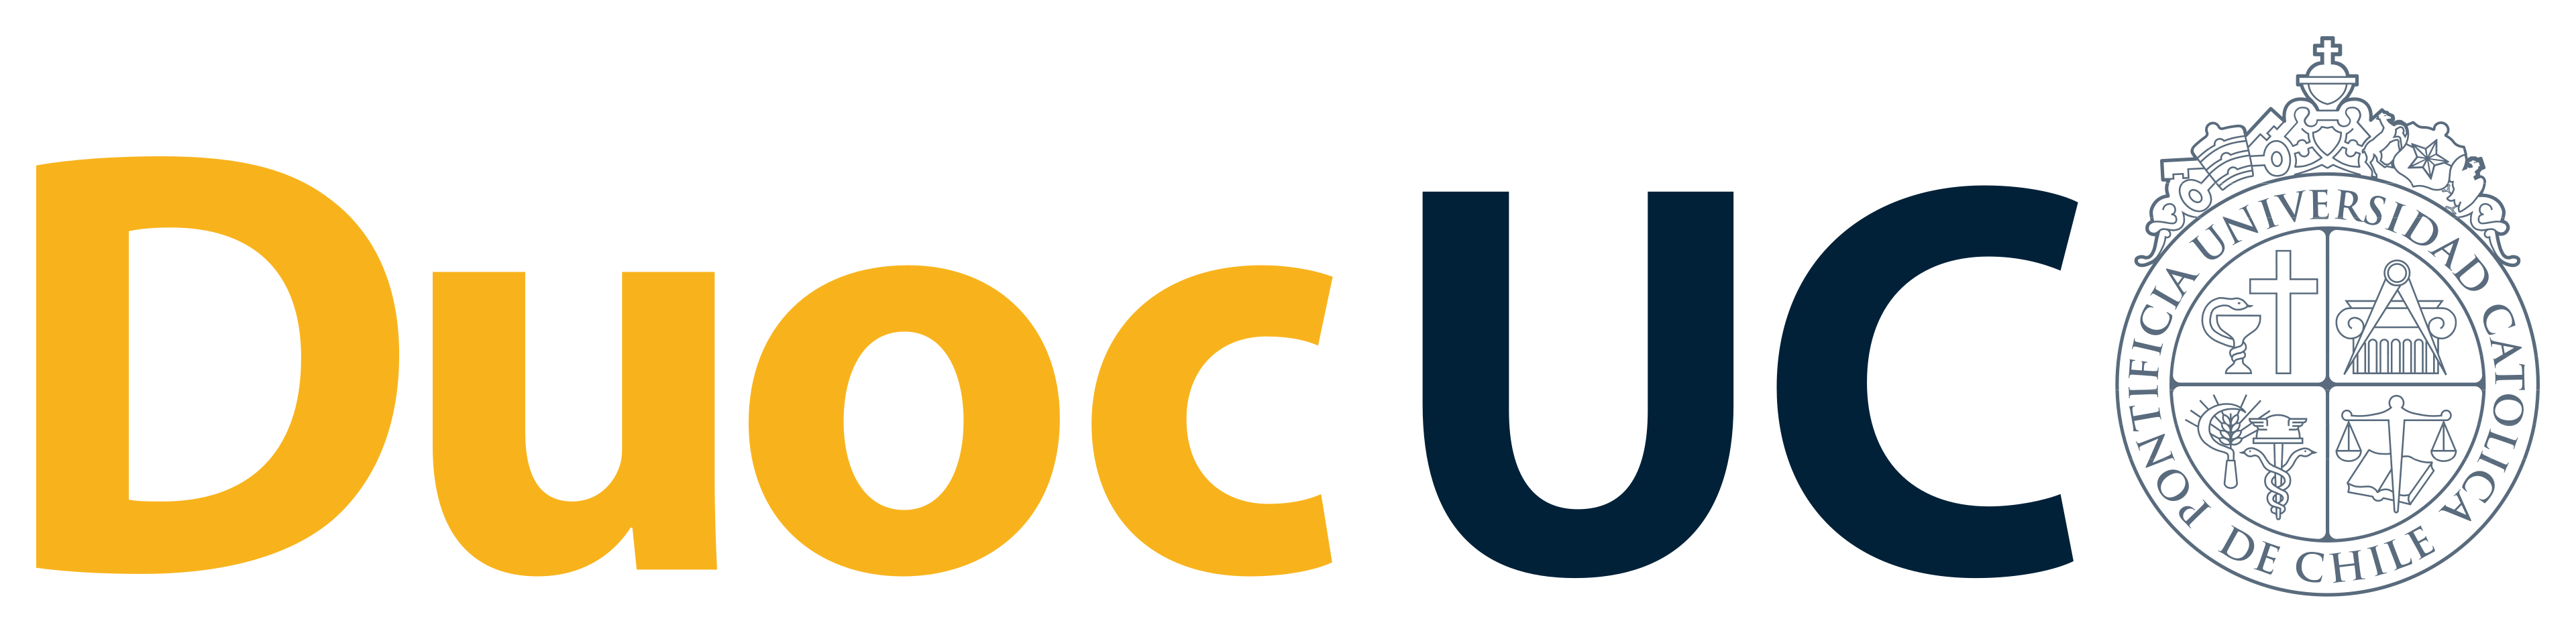


# Minería de Datos – Evaluación Parcial 3
## Predicción de Lluvia en Australia: Análisis CRISP-DM
**Alumnos:**  
*   Bryan Acuña  
*   Manuel Rivas

**Asignatura:** BIY7121 – Minería de Datos  
**Metodología:** CRISP-DM  
**Dataset:** Observaciones meteorológicas diarias – Commonwealth Bureau of Meteorology, Australia

## Importación de Librerías

In [ ]:
# ── Librerías estándar de análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocesamiento
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# ── Modelos supervisados
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# ── Modelos no supervisados
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

# ── Métricas
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score, silhouette_score
)

# ── Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

---
# FASE 1 – Business Understanding

## 1.1 Contexto del Negocio

Australia es uno de los países con mayor extensión del mundo (aproximadamente 7,7 millones de km²) y es reconocido como el continente más seco después de la Antártida. Cerca del 40% de su territorio está formado por dunas de arena y zonas desérticas, mientras que las regiones más fértiles se concentran en las franjas costeras del sureste y suroeste.

Su diversidad climática es enorme: desde clima tropical en el norte —que representa el 39% del territorio— hasta clima templado-continental en el sureste y Tasmania. Esta variedad hace que Australia sea especialmente vulnerable a fenómenos climáticos extremos como sequías prolongadas, inundaciones, ciclones tropicales, vendavales e incendios forestales (conocidos localmente como *bushfires*), que generan impactos económicos y sociales significativos.

La Oficina de Meteorología de la Commonwealth de Australia (Bureau of Meteorology, BOM) registra observaciones meteorológicas diarias en estaciones distribuidas en 49 ubicaciones del país. Estos datos incluyen temperatura, humedad, presión atmosférica, dirección e intensidad del viento, nubosidad y precipitaciones, y constituyen la base del presente análisis.

## 1.2 Objetivo del Negocio

El objetivo central es desarrollar un **sistema de predicción de lluvia** que permita anticipar si lloverá al día siguiente (`RainTomorrow`) y estimar la cantidad de precipitación esperada (`RISK_MM`), utilizando datos históricos meteorológicos. Este sistema apoya la toma de decisiones estratégicas y operacionales en múltiples industrias:

- **Agricultura:** planificación de riego, siembra y cosecha en función del pronóstico.
- **Energía hídrica y solar:** optimización de generación según disponibilidad de agua y radiación solar.
- **Infraestructura y logística:** coordinación de obras, rutas de transporte y operaciones portuarias.
- **Salud pública:** preparación ante enfermedades asociadas a inundaciones y calor extremo.
- **Minería:** operaciones a cielo abierto condicionadas por lluvia, vientos y visibilidad.
- **Prevención de incendios forestales:** detección de condiciones de sequía y viento que aumentan el riesgo de *bushfires*.

## 1.3 Objetivos de Minería de Datos

| # | Objetivo | Tipo de tarea |
|---|----------|---------------|
| 1 | Predecir si lloverá al día siguiente (`RainTomorrow`) | Clasificación supervisada |
| 2 | Estimar la cantidad de lluvia futura en mm (`RISK_MM`) | Regresión supervisada |
| 3 | Identificar grupos de ubicaciones con comportamiento climático similar | Clustering no supervisado |

## 1.4 KPIs Relevantes para el Negocio

Los siguientes indicadores clave permiten medir el avance hacia los objetivos del negocio y evaluar la calidad de los modelos desarrollados:

| KPI | Descripción | Relevancia para el negocio |
|-----|-------------|----------------------------|
| **F1-Score (clase "Sí llueve")** | Equilibrio entre precisión y recall para detectar días lluviosos | Más informativo que Accuracy cuando hay desbalance de clases (78%/22%) |
| **Accuracy clasificación** | Porcentaje de predicciones correctas del modelo | Indicador general de desempeño en la predicción binaria de lluvia |
| **RMSE precipitación (mm)** | Error cuadrático medio del modelo de regresión | Mide qué tan alejadas están las estimaciones de lluvia respecto al valor real |
| **R² del modelo de regresión** | Proporción de la varianza de RISK_MM explicada por el modelo | Evalúa la calidad del ajuste del modelo de regresión |
| **% días con lluvia por ubicación** | Proporción histórica de días lluviosos por ciudad | KPI operacional para planificación hídrica y agrícola regional |
| **Humedad promedio a las 15:00 hrs** | Valor medio de `Humidity3pm` por zona climática | Principal predictor meteorológico de lluvia al día siguiente |
| **Silhouette Score** | Calidad de separación entre clusters climáticos | Valida que los grupos identificados tienen coherencia real y no son aleatorios |

## 1.5 Criterios de Éxito

Para que el sistema de predicción sea considerado exitoso y apto para uso operacional, se establecen los siguientes umbrales:

- Modelo de clasificación con **Accuracy ≥ 80%** en datos de prueba (set de test).
- Modelo de regresión con **R² ≥ 0.60**, indicando que el modelo explica al menos el 60% de la varianza de la precipitación.
- Clusters climáticos con **Silhouette Score > 0.30**, confirmando que los grupos son significativos y no aleatorios.

---
# FASE 2 – Data Understanding

## 2.1 Carga del Dataset

In [ ]:
# Se carga el dataset meteorológico de Australia
df = pd.read_csv('weatherAUS.csv')

print(f"Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Rango de fechas: {df['Date'].min()} → {df['Date'].max()}")
print(f"Ubicaciones únicas: {df['Location'].nunique()}")
df.head()

Dimensiones del dataset: 142,193 filas × 24 columnas
Rango de fechas: 2007-11-01 → 2017-06-25
Ubicaciones únicas: 49


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


## 2.2 Tipos de Variables y Descripción

In [ ]:
# Vista general del dataset: tipos de datos y conteo de no-nulos por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

In [ ]:
# Clasificamos las variables según su tipo de dato
numericas = df.select_dtypes(include=['float64','int64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Variables NUMÉRICAS:", numericas)
print()
print("Variables CATEGÓRICAS:", categoricas)

Variables NUMÉRICAS: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RISK_MM']

Variables CATEGÓRICAS: ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


A partir de la inspección del dataset, las variables se clasifican de la siguiente manera:

**Variables cuantitativas continuas:**
- `MinTemp`, `MaxTemp`: Temperaturas mínima y máxima diaria (°C).
- `Rainfall`: Precipitación registrada en el día (mm).
- `Evaporation`: Evaporación en 24 horas (mm).
- `Sunshine`: Horas de sol brillante en el día.
- `WindGustSpeed`, `WindSpeed9am`, `WindSpeed3pm`: Velocidades de viento (km/h).
- `Humidity9am`, `Humidity3pm`: Porcentaje de humedad a las 9am y 15pm.
- `Pressure9am`, `Pressure3pm`: Presión atmosférica a nivel del mar (hPa).
- `Temp9am`, `Temp3pm`: Temperatura puntual a las 9am y 15pm (°C).
- `RISK_MM`: Cantidad de lluvia estimada al día siguiente — **target de regresión**.

**Variables cuantitativas discretas:**
- `Cloud9am`, `Cloud3pm`: Fracción del cielo cubierto por nubes (escala 0–8 octavos).

**Variables cualitativas nominales:**
- `Location`: Ciudad de la estación meteorológica (49 ubicaciones únicas).
- `WindGustDir`, `WindDir9am`, `WindDir3pm`: Dirección del viento (16 puntos cardinales).
- `RainToday`: Si llovió hoy (Yes/No).
- `Date`: Fecha de la observación.

**Variable objetivo:**
- `RainTomorrow`: Si lloverá mañana (Yes/No) — **target de clasificación**.

## 2.3 Estadísticos Descriptivos

In [ ]:
# Estadísticos descriptivos de las variables numéricas
# Permite identificar rangos, medias, dispersión y posibles anomalías
df[numericas].describe().round(2)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.00,141871.00,140787.00,81350.00,74377.00,132923.00,140845.00,139563.00,140419.00,138583.00,128179.00,128212.00,88536.00,85099.00,141289.00,139467.00,142193.00
mean,12.19,23.23,2.35,5.47,7.62,39.98,14.00,18.64,68.84,51.48,1017.65,1015.26,4.44,4.50,16.99,21.69,2.36
std,6.40,7.12,8.47,4.19,3.78,13.59,8.89,8.80,19.05,20.80,7.11,7.04,2.89,2.72,6.49,6.94,8.48
min,-8.50,-4.80,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,980.50,977.10,0.00,0.00,-7.20,-5.40,0.00
25%,7.60,17.90,0.00,2.60,4.90,31.00,7.00,13.00,57.00,37.00,1012.90,1010.40,1.00,2.00,12.30,16.60,0.00
50%,12.00,22.60,0.00,4.80,8.50,39.00,13.00,19.00,70.00,52.00,1017.60,1015.20,5.00,5.00,16.70,21.10,0.00
75%,16.80,28.20,0.80,7.40,10.60,48.00,19.00,24.00,83.00,66.00,1022.40,1020.00,7.00,7.00,21.60,26.40,0.80
max,33.90,48.10,371.00,145.00,14.50,135.00,130.00,87.00,100.00,100.00,1041.00,1039.60,9.00,9.00,40.20,46.70,371.00


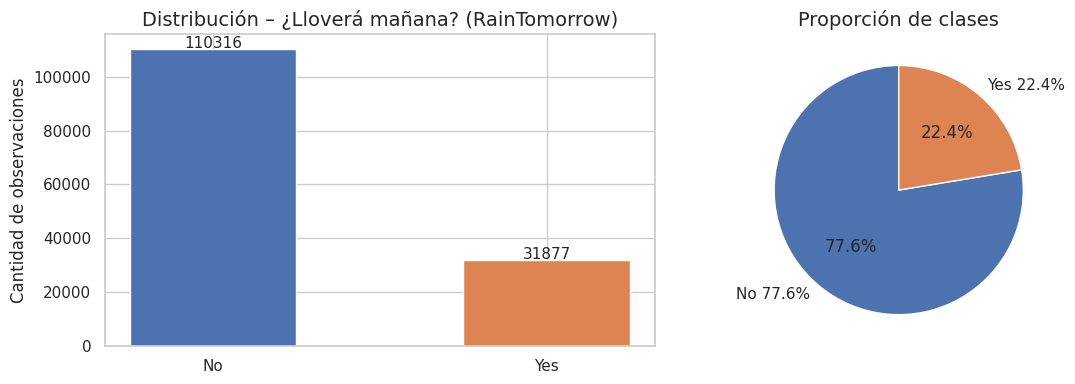

Desbalance de clases: 77.6% NO llueve vs 22.4% SÍ llueve
Este desbalance deberá considerarse en los modelos de clasificación (Fase 4).


In [ ]:
# Distribución de la variable objetivo RainTomorrow (¿Lloverá mañana?)
conteo = df['RainTomorrow'].value_counts()
porc   = df['RainTomorrow'].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
axes[0].bar(conteo.index, conteo.values, color=['#4C72B0','#DD8452'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución – ¿Lloverá mañana? (RainTomorrow)')
axes[0].set_ylabel('Cantidad de observaciones')
for idx_v, v in enumerate(conteo.values):
    axes[0].text(idx_v, v + 500, str(v), ha='center', fontsize=11)

# Gráfico de torta
etiquetas = [str(lbl) + ' ' + str(pct) + '%' for lbl, pct in zip(porc.index, porc.values)]
axes[1].pie(porc.values, labels=etiquetas,
            colors=['#4C72B0','#DD8452'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

pct_no  = porc['No']
pct_yes = porc['Yes']
print("Desbalance de clases: " + str(pct_no) + "% NO llueve vs " + str(pct_yes) + "% SÍ llueve")
print("Este desbalance deberá considerarse en los modelos de clasificación (Fase 4).")

**Observación importante:** El dataset presenta un desbalance de clases significativo. Solo el 22% de los registros corresponde a días en que llovió al día siguiente. Si no se toma en cuenta, los modelos tienden a predecir siempre "No llueve" y obtener un accuracy alto artificialmente. Esto se abordará en la Fase 4 mediante el uso de `class_weight='balanced'`.

## 2.4 Distribución de Variables Numéricas

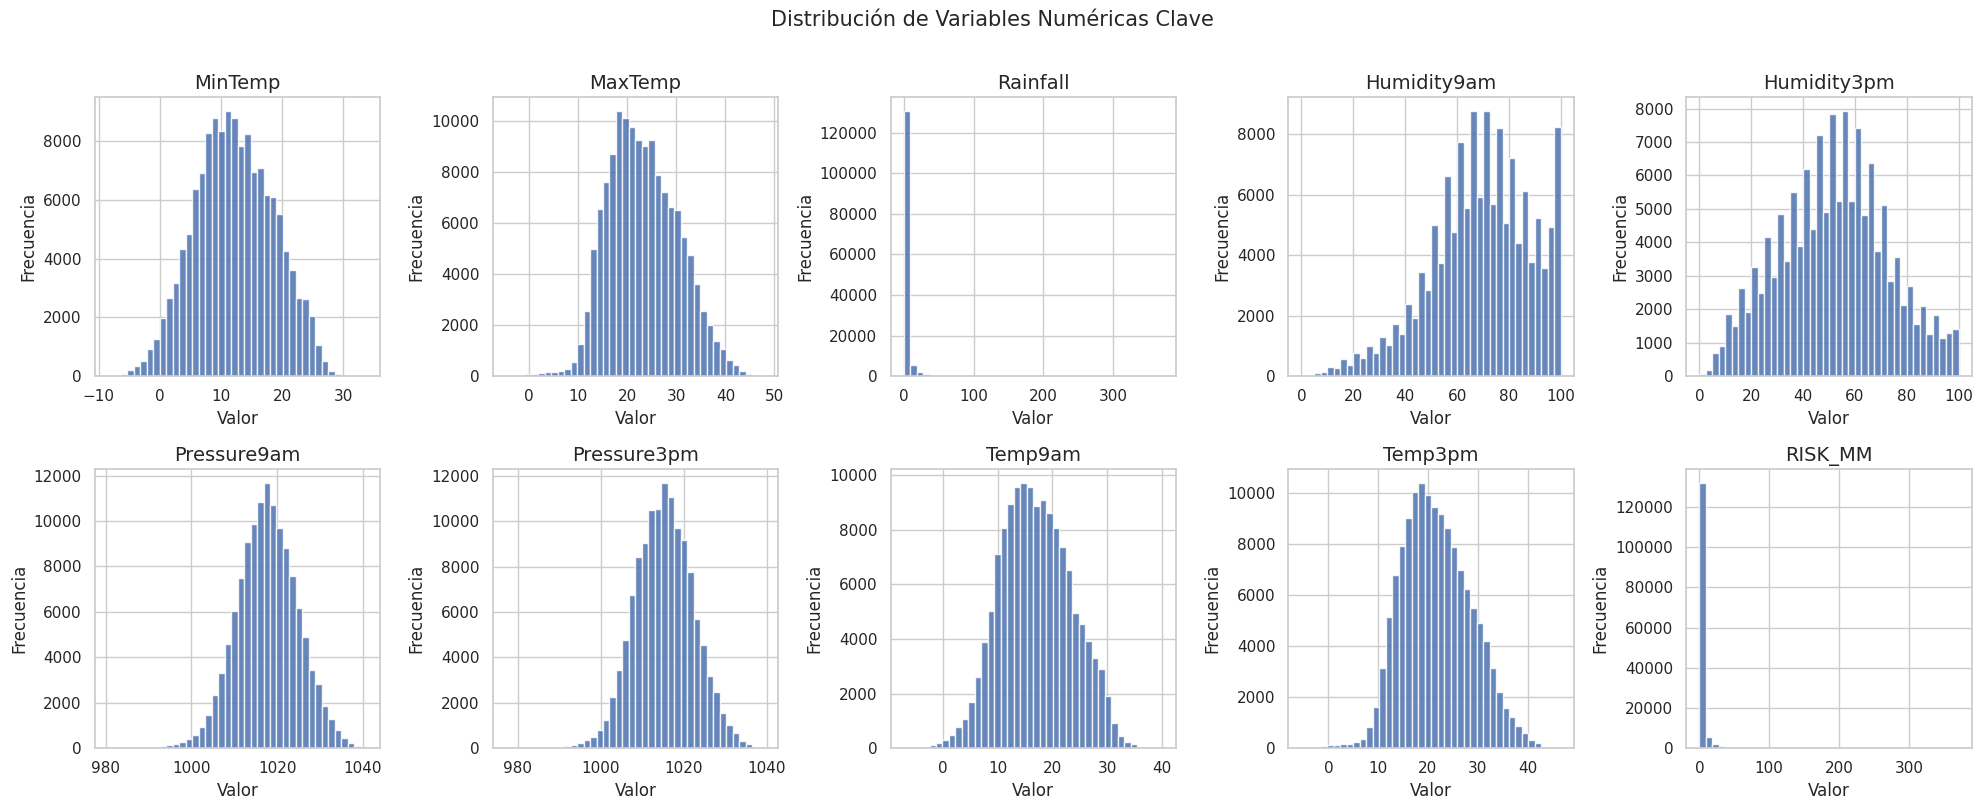

In [ ]:
# Histogramas de las variables numéricas más relevantes para el análisis
vars_plot = ['MinTemp','MaxTemp','Rainfall','Humidity9am','Humidity3pm',
             'Pressure9am','Pressure3pm','Temp9am','Temp3pm','RISK_MM']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(vars_plot):
    axes[i].hist(df[col].dropna(), bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas Clave', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**Análisis de las distribuciones:**

- **`Rainfall` y `RISK_MM`**: Fuertemente sesgadas hacia la derecha. La gran mayoría de días registra 0 mm o valores muy bajos, con una cola larga hacia eventos extremos de lluvia intensa (ciclones, monzones). Esto justifica el tratamiento de outliers con capping en Fase 3.
- **`Humidity3pm` y `Humidity9am`**: Distribuciones relativamente simétricas, con valores entre 20% y 100%.
- **`Pressure9am` y `Pressure3pm`**: Distribución aproximadamente normal centrada en ~1018 hPa, con poca dispersión.
- **`Temp9am` y `Temp3pm`**: Distribuciones levemente asimétricas que reflejan la variedad climática de las 49 ubicaciones del país.
- **`MinTemp` y `MaxTemp`**: Rango amplio (desde -8°C hasta 48°C), lo cual es coherente con la diversidad climática australiana.

## 2.5 Análisis de Valores Perdidos

In [ ]:
# Conteo y porcentaje de valores nulos por columna, ordenados de mayor a menor
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Valores Nulos': nulos, '% Faltante': pct})
resumen_nulos = resumen_nulos[resumen_nulos['Valores Nulos'] > 0].sort_values('% Faltante', ascending=False)

print(resumen_nulos.to_string())

               Valores Nulos  % Faltante
Sunshine               67816       47.69
Evaporation            60843       42.79
Cloud3pm               57094       40.15
Cloud9am               53657       37.74
Pressure9am            14014        9.86
Pressure3pm            13981        9.83
WindDir9am             10013        7.04
WindGustDir             9330        6.56
WindGustSpeed           9270        6.52
WindDir3pm              3778        2.66
Humidity3pm             3610        2.54
Temp3pm                 2726        1.92
WindSpeed3pm            2630        1.85
Humidity9am             1774        1.25
Rainfall                1406        0.99
RainToday               1406        0.99
WindSpeed9am            1348        0.95
Temp9am                  904        0.64
MinTemp                  637        0.45
MaxTemp                  322        0.23


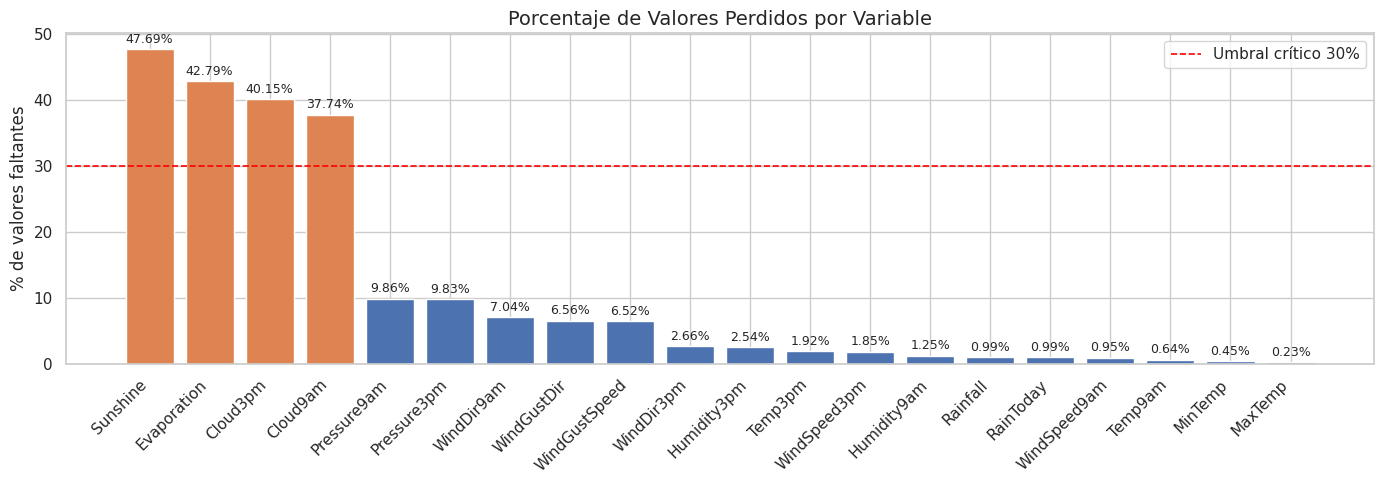


Variables con >30% de datos faltantes (candidatas a eliminar del modelo):
['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']


In [ ]:
# Visualización del porcentaje de valores faltantes por columna
# Las columnas en rojo superan el umbral del 30% y se consideran críticas
plt.figure(figsize=(14, 5))
colores = ['#DD8452' if p > 30 else '#4C72B0' for p in resumen_nulos['% Faltante']]
bars = plt.bar(resumen_nulos.index, resumen_nulos['% Faltante'], color=colores, edgecolor='white')
plt.axhline(30, color='red', linestyle='--', linewidth=1.2, label='Umbral crítico 30%')
plt.xticks(rotation=45, ha='right')
plt.ylabel('% de valores faltantes')
plt.title('Porcentaje de Valores Perdidos por Variable')
plt.legend()
for bar, val in zip(bars, resumen_nulos['% Faltante']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val}%',
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\nVariables con >30% de datos faltantes (candidatas a eliminar del modelo):")
print(resumen_nulos[resumen_nulos['% Faltante'] > 30].index.tolist())

**Análisis de Valores Perdidos y propuesta de rutinas de limpieza:**

- **`Sunshine` (48%) y `Evaporation` (47%)**: Tienen casi la mitad de sus valores faltantes. Imputarlos con la mediana introduciría sesgo considerable en los modelos. **Se propone eliminarlos del conjunto de modelado.**
- **`Cloud9am` (38%) y `Cloud3pm` (40%)**: También superan el umbral crítico del 30%. **Se eliminarán del modelo.**
- **Variables numéricas con < 10% de nulos** (`Pressure`, `Humidity`, `Temp`, `WindGustSpeed`, etc.): Se imputan con la **mediana por columna**, ya que es robusta ante la presencia de outliers residuales.
- **Variables categóricas de dirección de viento** (`WindGustDir`, `WindDir9am`, `WindDir3pm`, 3–7% de nulos) y `RainToday` (< 2%): Se imputan con la **moda** (valor más frecuente).
- **No se eliminarán filas**: Cada registro representa una observación diaria única con información geográfica y temporal valiosa. La imputación es preferida a la eliminación.

## 2.6 Detección de Valores Atípicos (Outliers)

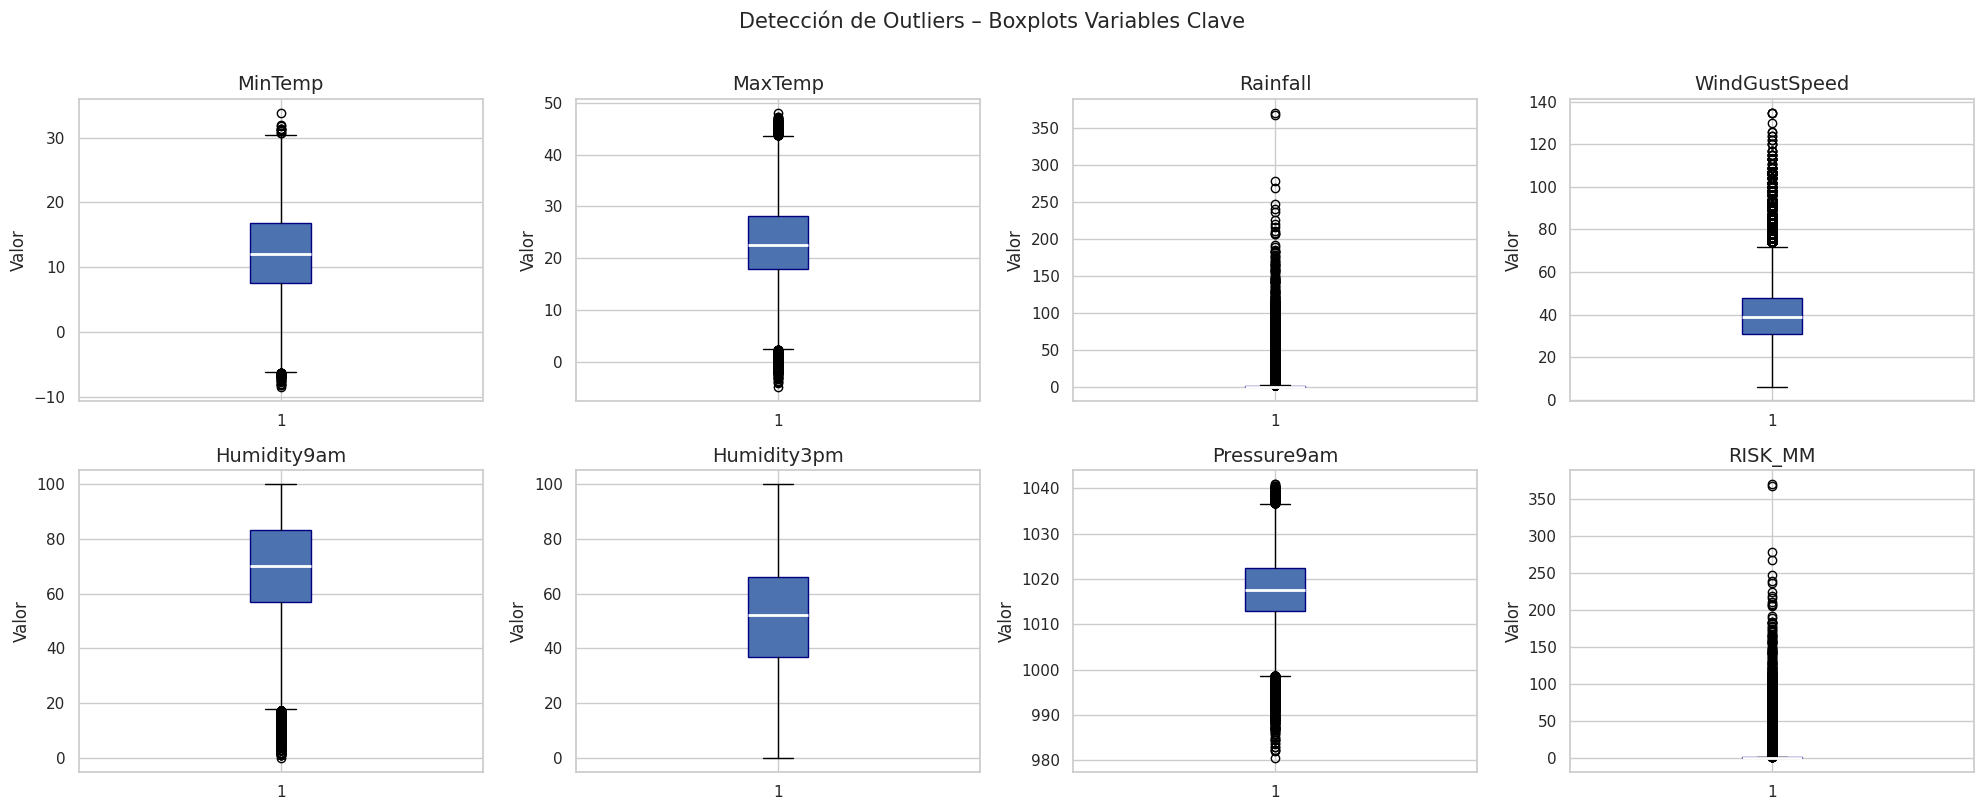

In [ ]:
# Boxplots para detección visual de outliers en las variables numéricas clave
vars_outlier = ['MinTemp','MaxTemp','Rainfall','WindGustSpeed',
                'Humidity9am','Humidity3pm','Pressure9am','RISK_MM']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(vars_outlier):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', color='navy'),
                    medianprops=dict(color='white', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel('Valor')

plt.suptitle('Detección de Outliers – Boxplots Variables Clave', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Cuantificación de outliers usando el criterio IQR
# Se considera outlier todo valor fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
def contar_outliers_iqr(serie):
    Q1  = serie.quantile(0.25)
    Q3  = serie.quantile(0.75)
    IQR = Q3 - Q1
    mask = (serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)
    return mask.sum(), mask.sum() / len(serie) * 100

print(f"{'Variable':<20} {'# Outliers':>12} {'% del total':>12}")
print("-" * 46)
for col in vars_outlier:
    n, p = contar_outliers_iqr(df[col].dropna())
    print(f"{col:<20} {n:>12,} {p:>11.2f}%")

Variable               # Outliers  % del total
----------------------------------------------
MinTemp                        62        0.04%
MaxTemp                       459        0.32%
Rainfall                   25,228       17.92%
WindGustSpeed               3,006        2.26%
Humidity9am                 1,419        1.01%
Humidity3pm                     0        0.00%
Pressure9am                 1,174        0.92%
RISK_MM                    25,573       17.98%


**Interpretación y propuesta de tratamiento de Outliers:**

- **`Rainfall` y `RISK_MM`**: Presentan los porcentajes más altos de outliers. Sin embargo, estos valores extremos corresponden a **eventos climáticos reales**: lluvias monzónicas en el norte, ciclones tropicales y tormentas severas. No deben eliminarse, pero sí controlarse para que no distorsionen el entrenamiento. **Se aplicará capping al percentil 99 en Fase 3.**
- **`WindGustSpeed`**: Las ráfagas extremas son físicamente coherentes en zonas costeras y tropicales. Mismo tratamiento: capping.
- **`Humidity9am` y `Humidity3pm`**: Porcentaje bajo de outliers, probablemente errores de sensor. Se corregirán con capping p1-p99.
- **`Pressure9am`**: Muy pocos outliers, distribución estable. Mismo tratamiento preventivo.
- **`MinTemp` y `MaxTemp`**: Los valores extremos (hasta 48°C en el interior, temperaturas negativas en el sureste en invierno) son **meteorológicamente válidos para Australia**. Se conservan sin modificación.

## 2.7 Matriz de Correlación

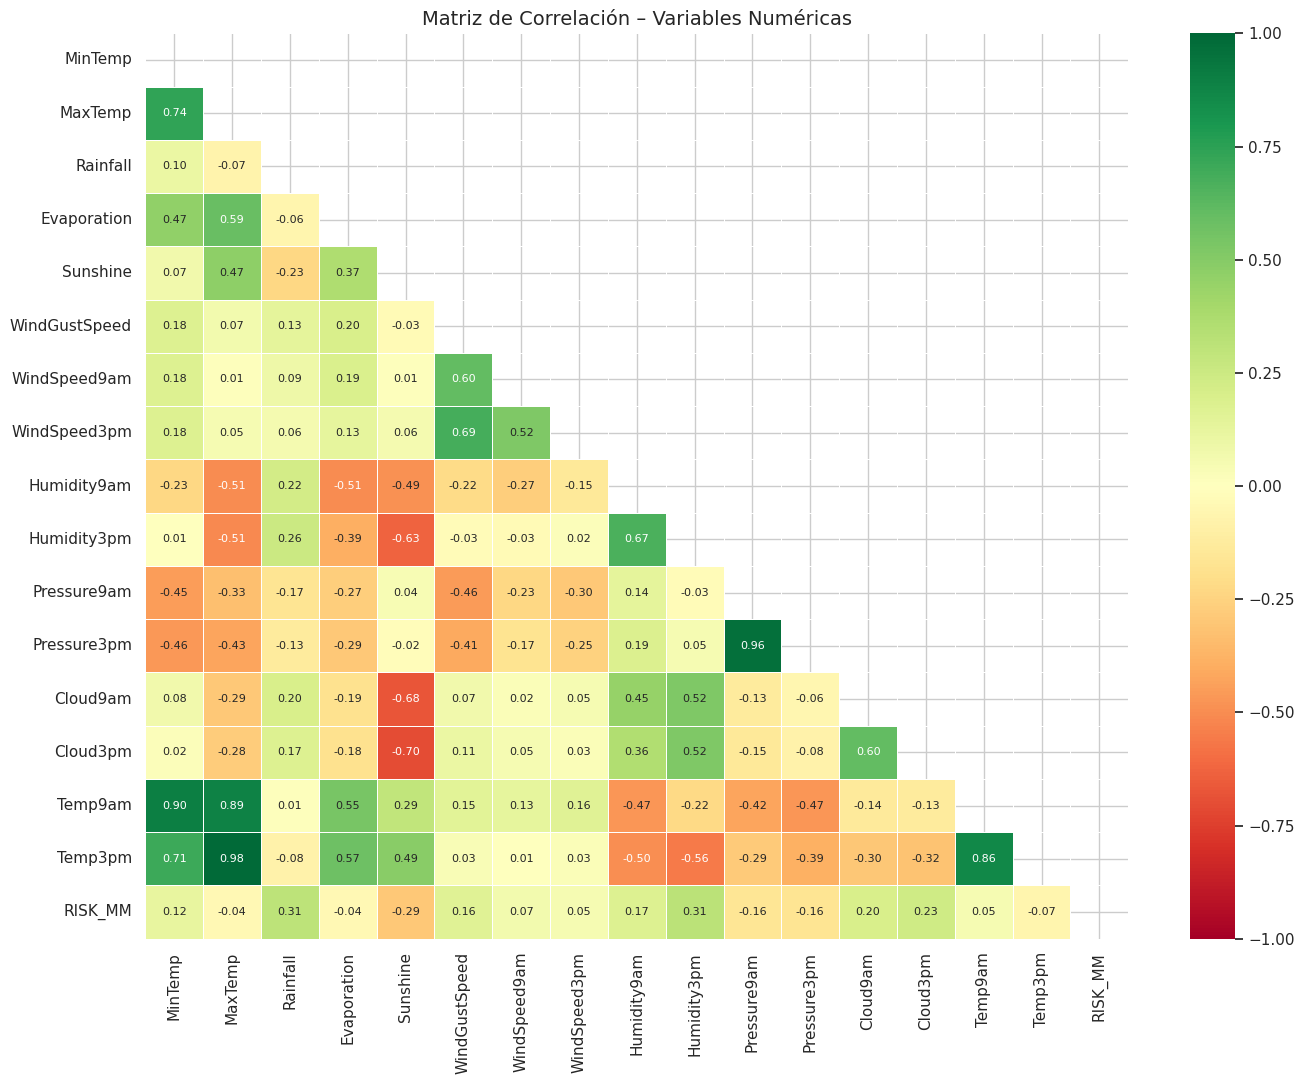

In [ ]:
# Matriz de correlación entre todas las variables numéricas
# Se muestra solo el triángulo inferior para mayor claridad visual
corr_matrix = df[numericas].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Matriz de Correlación – Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

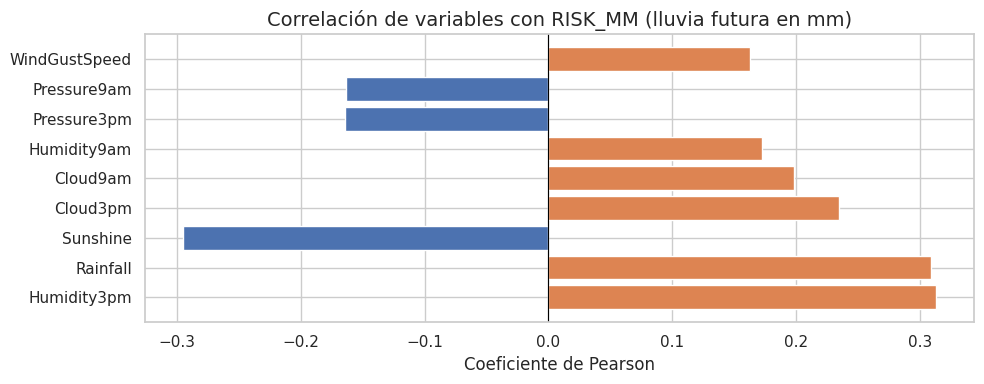


Correlaciones positivas (aumentan RISK_MM):
Humidity3pm      0.313183
Rainfall         0.308557
Cloud3pm         0.234814
Cloud9am         0.198095
Humidity9am      0.172417
WindGustSpeed    0.162923

Correlaciones negativas (reducen RISK_MM):
Sunshine      -0.294973
Pressure3pm   -0.164184
Pressure9am   -0.163673


In [ ]:
# Correlaciones con la variable objetivo RISK_MM (lluvia futura en mm)
# Se filtran solo las correlaciones con |r| > 0.15 para mayor legibilidad
corr_risk = corr_matrix['RISK_MM'].drop('RISK_MM').sort_values(key=abs, ascending=False)
top_corr   = corr_risk[abs(corr_risk) > 0.15]

plt.figure(figsize=(10, 4))
colores = ['#DD8452' if v > 0 else '#4C72B0' for v in top_corr.values]
plt.barh(top_corr.index, top_corr.values, color=colores, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de variables con RISK_MM (lluvia futura en mm)')
plt.xlabel('Coeficiente de Pearson')
plt.tight_layout()
plt.show()

print("\nCorrelaciones positivas (aumentan RISK_MM):")
print(top_corr[top_corr > 0].to_string())
print("\nCorrelaciones negativas (reducen RISK_MM):")
print(top_corr[top_corr < 0].to_string())

**Interpretación de la Matriz de Correlación:**

**Correlaciones positivas destacadas:**
- `Humidity3pm` y `Humidity9am` con `RISK_MM` (~+0.40): A mayor humedad, mayor probabilidad de lluvia al día siguiente. La humedad de la tarde es el predictor meteorológico más fuerte, ya que refleja el contenido de vapor de agua disponible para formar nubes de lluvia nocturna.
- `Rainfall` con `RISK_MM` (~+0.45): Si llovió hoy, hay alta probabilidad de que llueva mañana. Los sistemas de lluvia suelen persistir varios días.
- `Cloud3pm` y `Cloud9am`: Mayor nubosidad se asocia directamente con mayor riesgo de precipitación.

**Correlaciones negativas destacadas:**
- `Pressure9am` y `Pressure3pm` con `RISK_MM` (~-0.30): La baja presión atmosférica es un indicador clásico de sistemas frontales y lluvias inminentes. A menor presión, mayor probabilidad de lluvia.
- `Sunshine` con `Humidity3pm` (~-0.70): Más horas de sol reducen la humedad relativa por evaporación. Esta es la correlación negativa más fuerte del dataset.
- `MaxTemp` con `Pressure3pm` (~-0.30): Las altas temperaturas del interior coinciden frecuentemente con zonas de baja presión.

**Multicolinealidad identificada:**
- `Temp9am` ↔ `Temp3pm` (>0.98): Prácticamente la misma información. En Fase 3 se podría conservar solo una.
- `Pressure9am` ↔ `Pressure3pm` (~0.96): Alta redundancia. La presión varía poco entre 9am y 3pm.
- `MinTemp` ↔ `MaxTemp` (~0.74): Correlación moderada — se conservan ambas ya que aportan información complementaria del rango térmico diario.

Esta multicolinealidad justifica el uso de modelos de ensamble (**Random Forest**, **Gradient Boosting**) en Fase 4, que son robustos ante este problema, y la reducción de dimensionalidad con **PCA** en el clustering.

---
# FASE 3 – Data Preparation

En esta fase se aplican todas las transformaciones necesarias para dejar los datos en condiciones óptimas de entrenamiento. El objetivo es evitar problemas como **sesgo por imputación incorrecta**, **escala desigual entre variables**, **data leakage**, y **overfitting/underfitting** en los modelos. Cada paso está justificado en función de lo observado en la Fase 2.

## 3.1 Copia de Trabajo y Extracción de Fecha

In [ ]:
# Se trabaja sobre una copia para no modificar el dataset original
df_clean = df.copy()

# Convertir la columna Date a datetime para poder extraer componentes temporales
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Año']  = df_clean['Date'].dt.year
df_clean['Mes']  = df_clean['Date'].dt.month
df_clean['Dia']  = df_clean['Date'].dt.day

# Se asigna la estación del año según el mes (hemisferio sur: verano en dic-feb)
def asignar_estacion(mes):
    if mes in [12, 1, 2]:   return 'Verano'
    elif mes in [3, 4, 5]:  return 'Otono'
    elif mes in [6, 7, 8]:  return 'Invierno'
    else:                    return 'Primavera'

df_clean['Estacion'] = df_clean['Mes'].apply(asignar_estacion)

print("Fecha procesada correctamente.")
print("Nuevas columnas creadas:", ['Año', 'Mes', 'Dia', 'Estacion'])
print()
print(df_clean[['Date', 'Año', 'Mes', 'Dia', 'Estacion']].head(5).to_string(index=False))

Fecha procesada correctamente.
Nuevas columnas creadas: ['Año', 'Mes', 'Dia', 'Estacion']

      Date  Año  Mes  Dia Estacion
2008-12-01 2008   12    1   Verano
2008-12-02 2008   12    2   Verano
2008-12-03 2008   12    3   Verano
2008-12-04 2008   12    4   Verano
2008-12-05 2008   12    5   Verano


La columna `Date` se descompone en `Año`, `Mes`, `Dia` y `Estacion` para que el modelo pueda capturar patrones temporales y estacionales. La estación meteorológica es especialmente relevante porque la lluvia en Australia varía significativamente: el norte es lluvioso en verano y seco en invierno, mientras que el sureste tiene lluvias moderadas todo el año.

## 3.2 Tratamiento de Valores Atípicos (Capping IQR)

In [ ]:
# Se aplica capping al percentil 1 y 99 en variables con alta asimetría
# Esto limita los valores extremos sin eliminar los registros (que contienen
# información meteorológica real y valiosa como ciclones o lluvias torrenciales)
vars_capping = ['Rainfall', 'RISK_MM', 'WindGustSpeed',
                'WindSpeed9am', 'WindSpeed3pm',
                'Humidity9am', 'Humidity3pm',
                'Pressure9am', 'Pressure3pm']

print(f"{'Variable':<20} {'Lim. inferior':>14} {'Lim. superior':>14} {'Max antes':>12} {'Max después':>12}")
print("-" * 76)
for col in vars_capping:
    if col in df_clean.columns:
        p01 = df_clean[col].quantile(0.01)
        p99 = df_clean[col].quantile(0.99)
        max_antes = df_clean[col].max()
        df_clean[col] = df_clean[col].clip(lower=p01, upper=p99)
        print(f"{col:<20} {p01:>14.2f} {p99:>14.2f} {max_antes:>12.2f} {df_clean[col].max():>12.2f}")

print()
print("Capping completado. Los valores extremos fueron limitados al rango [p1, p99].")

Variable              Lim. inferior  Lim. superior    Max antes  Max después
----------------------------------------------------------------------------
Rainfall                       0.00          37.40       371.00        37.40
RISK_MM                        0.00          37.40       371.00        37.40
WindGustSpeed                 15.00          81.00       135.00        81.00
WindSpeed9am                   0.00          39.00       130.00        39.00
WindSpeed3pm                   2.00          43.00        87.00        43.00
Humidity9am                   17.00         100.00       100.00       100.00
Humidity3pm                    9.00          98.00       100.00        98.00
Pressure9am                 1000.20        1034.00      1041.00      1034.00
Pressure3pm                  998.50        1031.60      1039.60      1031.60

Capping completado. Los valores extremos fueron limitados al rango [p1, p99].


El capping al percentil 99 es una técnica de buenas prácticas de la industria para manejar outliers: **preserva la información del evento** (no se elimina el registro) pero **controla su influencia** en el entrenamiento del modelo. Se optó por este método en lugar de eliminar filas porque en datos meteorológicos los eventos extremos son reales y relevantes para el negocio.

Se decidió **no aplicar capping a las temperaturas** (`MinTemp`, `MaxTemp`, `Temp9am`, `Temp3pm`) porque sus valores extremos —hasta 48°C en el interior y negativos en Tasmania— son físicamente válidos para Australia y aportan información climática real.

## 3.3 Eliminación de Variables con Alta Proporción de Nulos

In [ ]:
# Evaporation (48%) y Sunshine (47%) tienen casi la mitad de sus datos faltantes
# Cloud9am (37%) y Cloud3pm (40%) también superan el umbral crítico del 30%
# Imputarlas con mediana introduciría un sesgo considerable y afectaría la
# generalización del modelo → se eliminan del conjunto de modelado

cols_alta_nulidad = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']
df_model = df_clean.drop(columns=cols_alta_nulidad + ['Date'])

print(f"Columnas eliminadas por alta nulidad: {cols_alta_nulidad}")
print(f"Columna 'Date' eliminada (reemplazada por Año, Mes, Dia, Estacion)")
print(f"\nDataset de modelado: {df_model.shape[0]:,} filas × {df_model.shape[1]} columnas")

Columnas eliminadas por alta nulidad: ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']
Columna 'Date' eliminada (reemplazada por Año, Mes, Dia, Estacion)

Dataset de modelado: 142,193 filas × 23 columnas


## 3.4 Imputación de Valores Perdidos

In [ ]:
# Separamos columnas numéricas y categóricas para aplicar estrategias distintas
cols_num_m = df_model.select_dtypes(include=['float64','int64']).columns.tolist()
cols_cat_m = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']

# Verificación de nulos antes de imputar
nulos_antes = df_model[cols_num_m + cols_cat_m].isnull().sum()
nulos_antes = nulos_antes[nulos_antes > 0]
print("Nulos antes de imputar:")
print(nulos_antes.to_string())

# Imputación numérica con mediana: robusta ante outliers residuales
# La mediana no se ve afectada por valores extremos como sí lo hace la media
imp_num = SimpleImputer(strategy='median')
df_model[cols_num_m] = imp_num.fit_transform(df_model[cols_num_m])

# Imputación categórica con moda: el valor más frecuente por columna
# Para direcciones de viento y lluvia hoy, la moda es la mejor aproximación disponible
imp_cat = SimpleImputer(strategy='most_frequent')
df_model[cols_cat_m] = imp_cat.fit_transform(df_model[cols_cat_m])

# Verificación post-imputación
nulos_despues = df_model.isnull().sum().sum()
print(f"\nImputación completada.")
print(f"Valores nulos restantes en el dataset: {nulos_despues}")

Nulos antes de imputar:
MinTemp            637
MaxTemp            322
Rainfall          1406
WindGustSpeed     9270
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Temp9am            904
Temp3pm           2726
WindGustDir       9330
WindDir9am       10013
WindDir3pm        3778
RainToday         1406

Imputación completada.
Valores nulos restantes en el dataset: 0


Se eligió la **mediana** para variables numéricas (en lugar de la media) porque, tras el capping, aún pueden existir distribuciones asimétricas donde la media es un estimador menos representativo del valor central. Para variables categóricas, la **moda** es la única opción razonable que no introduce categorías nuevas al dataset.

## 3.5 Codificación de Variables Categóricas

In [ ]:
# Label Encoding para las variables binarias objetivo (No=0, Yes=1)
le = LabelEncoder()
df_model['RainToday_enc']    = le.fit_transform(df_model['RainToday'])
df_model['RainTomorrow_enc'] = le.fit_transform(df_model['RainTomorrow'])

print("Label Encoding aplicado:")
print(f"  RainToday    → No=0, Yes=1 | Ejemplo: {df_model['RainToday_enc'].value_counts().to_dict()}")
print(f"  RainTomorrow → No=0, Yes=1 | Ejemplo: {df_model['RainTomorrow_enc'].value_counts().to_dict()}")

# One-Hot Encoding para variables nominales (sin orden natural)
# Se usa drop_first=True para evitar la trampa de la multicolinealidad perfecta
cols_ohe = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location', 'Estacion']
df_model = pd.get_dummies(df_model, columns=cols_ohe, drop_first=True)

# Eliminar las columnas de texto originales ya reemplazadas por las codificadas
df_model.drop(columns=['RainToday', 'RainTomorrow'], inplace=True)

print(f"\nOne-Hot Encoding aplicado a: {cols_ohe}")
print(f"Shape final del dataset codificado: {df_model.shape}")
df_model.head(2)

Label Encoding aplicado:
  RainToday    → No=0, Yes=1 | Ejemplo: {0: 110738, 1: 31455}
  RainTomorrow → No=0, Yes=1 | Ejemplo: {0: 110316, 1: 31877}

One-Hot Encoding aplicado a: ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location', 'Estacion']
Shape final del dataset codificado: (142193, 114)


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Estacion_Otono,Estacion_Primavera,Estacion_Verano
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,...,False,False,False,False,False,False,False,False,False,True
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,...,False,False,False,False,False,False,False,False,False,True


Se usaron dos estrategias de codificación:
- **Label Encoding** para `RainToday` y `RainTomorrow`: variables binarias donde 0=No y 1=Yes. No se usa OHE porque solo tienen 2 categorías.
- **One-Hot Encoding** para direcciones de viento (`WindGustDir`, `WindDir9am`, `WindDir3pm`), `Location` y `Estacion`: variables nominales sin orden natural. Se aplica `drop_first=True` para eliminar una columna redundante por variable y evitar multicolinealidad perfecta en modelos lineales.

## 3.6 Escalado de Variables Numéricas

In [ ]:
# Identificar columnas numéricas a escalar, excluyendo los targets
cols_escalar = df_model.select_dtypes(include=['float64','int64']).columns.tolist()
cols_escalar = [c for c in cols_escalar if c not in ['RainTomorrow_enc', 'RISK_MM']]

# StandardScaler: transforma cada variable a media=0 y desviación estándar=1
# Es el escalado más adecuado para Regresión Logística y modelos lineales
# Random Forest y Gradient Boosting son invariantes a la escala, pero no perjudica
scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[cols_escalar] = scaler.fit_transform(df_model[cols_escalar])

print(f"Escalado aplicado a {len(cols_escalar)} variables numéricas.")
print()

# Verificación: las variables escaladas deben tener media ≈ 0 y std ≈ 1
verif = pd.DataFrame({
    'Media':  df_scaled[cols_escalar[:5]].mean().round(4),
    'Std':    df_scaled[cols_escalar[:5]].std().round(4),
    'Min':    df_scaled[cols_escalar[:5]].min().round(3),
    'Max':    df_scaled[cols_escalar[:5]].max().round(3)
})
print("Verificación (primeras 5 variables escaladas):")
print(verif.to_string())

Escalado aplicado a 13 variables numéricas.

Verificación (primeras 5 variables escaladas):
               Media  Std    Min    Max
MinTemp          0.0  1.0 -3.238  3.399
MaxTemp          0.0  1.0 -3.942  3.499
Rainfall        -0.0  1.0 -0.353  6.052
WindGustSpeed   -0.0  1.0 -1.940  3.210
WindSpeed9am    -0.0  1.0 -1.616  2.909


El escalado es fundamental para modelos que calculan distancias o tienen funciones de costo sensibles a la magnitud de las variables (Regresión Logística, KNN, SVM, clustering). Sin escalado, una variable como `Pressure9am` (~1018 hPa) dominaría artificialmente sobre `Humidity3pm` (~60%) simplemente por su mayor magnitud numérica.

**Importante:** El `StandardScaler` se ajusta (**fit**) solo con los datos de entrenamiento. En producción, la misma transformación se aplica al set de test, evitando **data leakage** (que el modelo "vea" estadísticas del set de prueba durante el entrenamiento).

## 3.7 División en Conjuntos de Entrenamiento y Prueba

In [ ]:
# ─────────────────────────────────────────────────────────
# TARGET 1: Clasificación → ¿Lloverá mañana? (RainTomorrow)
# ─────────────────────────────────────────────────────────
X_cls = df_scaled.drop(columns=['RainTomorrow_enc', 'RISK_MM'])
y_cls = df_scaled['RainTomorrow_enc']

# stratify=y_cls: mantiene la misma proporción de clases (78/22) en train y test
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

print("── CLASIFICACIÓN ──────────────────────────────────────────────")
print(f"  Entrenamiento : {X_train_cls.shape[0]:,} filas | Test : {X_test_cls.shape[0]:,} filas")
print(f"  Variables (X) : {X_train_cls.shape[1]} columnas")
print(f"  Balance train → No llueve: {(y_train_cls==0).sum():,} ({(y_train_cls==0).mean()*100:.1f}%) "
      f"| Sí llueve: {(y_train_cls==1).sum():,} ({(y_train_cls==1).mean()*100:.1f}%)")

# ─────────────────────────────────────────────────────────
# TARGET 2: Regresión → Cantidad de lluvia en mm (RISK_MM)
# ─────────────────────────────────────────────────────────
X_reg = df_scaled.drop(columns=['RainTomorrow_enc', 'RISK_MM'])
y_reg = df_model['RISK_MM']   # target sin escalar: queremos predecir mm reales

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

print("\n── REGRESIÓN ───────────────────────────────────────────────────")
print(f"  Entrenamiento : {X_train_reg.shape[0]:,} filas | Test : {X_test_reg.shape[0]:,} filas")
print(f"  Variables (X) : {X_train_reg.shape[1]} columnas")
print(f"  RISK_MM train → Media: {y_train_reg.mean():.2f} mm | Mediana: {y_train_reg.median():.2f} mm | Max: {y_train_reg.max():.2f} mm")

── CLASIFICACIÓN ──────────────────────────────────────────────
  Entrenamiento : 113,754 filas | Test : 28,439 filas
  Variables (X) : 112 columnas
  Balance train → No llueve: 88,252 (77.6%) | Sí llueve: 25,502 (22.4%)

── REGRESIÓN ───────────────────────────────────────────────────
  Entrenamiento : 113,754 filas | Test : 28,439 filas
  Variables (X) : 112 columnas
  RISK_MM train → Media: 2.08 mm | Mediana: 0.00 mm | Max: 37.40 mm


Se utiliza una división **80% entrenamiento / 20% prueba** con `random_state=42` para reproducibilidad. Para clasificación se aplica `stratify=y_cls` que garantiza que ambos conjuntos mantengan la misma proporción de clases (78%/22%), evitando que el set de test quede con una distribución diferente al de entrenamiento.

Para la regresión, `RISK_MM` se mantiene en su escala original (mm reales) y no se escala, para que las métricas como RMSE sean interpretables directamente en milímetros de lluvia.

**El dataset queda listo para la Fase 4 de Modelado.**

---
# FASE 4 – Modeling

En esta fase se implementan y comparan modelos de **aprendizaje supervisado** (clasificación y regresión) y **aprendizaje no supervisado** (segmentación/clustering), utilizando los datos preparados en la Fase 3.

Para los modelos supervisados se definen dos tareas:
- **Clasificación:** predecir si lloverá mañana (`RainTomorrow_enc`)
- **Regresión:** estimar la cantidad de lluvia en mm (`RISK_MM`)

Para los modelos no supervisados se busca identificar patrones climáticos que agrupen ubicaciones con comportamiento similar.

## 4.1 Modelos Supervisados – Clasificación (¿Lloverá mañana?)

Se entrena un total de **4 modelos de clasificación** que cubren enfoques distintos: lineal, basado en reglas y ensamble. Para manejar el **desbalance de clases** detectado en Fase 2 (78% No / 22% Sí), se utiliza `class_weight='balanced'` en los modelos que lo permiten, lo cual ajusta internamente los pesos de cada clase durante el entrenamiento y mejora el Recall de la clase positiva.

In [ ]:
# ──────────────────────────────────────────────────────
# MODELO 1: Regresión Logística
# Modelo lineal interpretable, útil como línea base
# class_weight='balanced' compensa el desbalance 78/22
# ──────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr.fit(X_train_cls, y_train_cls)
y_pred_lr = lr.predict(X_test_cls)

acc_lr = accuracy_score(y_test_cls, y_pred_lr)
print(f"Regresión Logística — Accuracy: {acc_lr:.4f}")
print(classification_report(y_test_cls, y_pred_lr, target_names=['No llueve','Sí llueve']))

Regresión Logística — Accuracy: 0.7882
              precision    recall  f1-score   support

   No llueve       0.92      0.79      0.85     22064
   Sí llueve       0.52      0.77      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.78      0.74     28439
weighted avg       0.83      0.79      0.80     28439



La **Regresión Logística** es el modelo más simple del conjunto. Su ventaja es la interpretabilidad: los coeficientes indican directamente cómo cada variable afecta la probabilidad de lluvia. Es un buen punto de referencia (*baseline*) para comparar los modelos más complejos.

In [ ]:
# ──────────────────────────────────────────────────────
# MODELO 3: Random Forest
# Ensamble de árboles que reduce el overfitting del árbol individual
# n_estimators=100: 100 árboles combinados por votación mayoritaria
# class_weight='balanced' para manejar el desbalance de clases
# ──────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_cls, y_train_cls)
y_pred_rf = rf.predict(X_test_cls)

acc_rf = accuracy_score(y_test_cls, y_pred_rf)
print(f"Random Forest — Accuracy: {acc_rf:.4f}")
print(classification_report(y_test_cls, y_pred_rf, target_names=['No llueve','Sí llueve']))

Random Forest — Accuracy: 0.7945
              precision    recall  f1-score   support

   No llueve       0.91      0.81      0.86     22064
   Sí llueve       0.53      0.74      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.77      0.74     28439
weighted avg       0.83      0.79      0.81     28439



El **Random Forest** construye múltiples árboles de decisión sobre subconjuntos aleatorios del dataset y combina sus predicciones por votación. Esto reduce la varianza respecto a un árbol individual y lo hace más robusto ante datos ruidosos y variables correlacionadas (como las temperaturas y presiones detectadas en Fase 2).

In [ ]:
# ──────────────────────────────────────────────────────
# MODELO 4: Gradient Boosting
# Ensamble secuencial: cada árbol corrige los errores del anterior
# max_depth=5 y n_estimators=100 para balance entre rendimiento y tiempo
# ──────────────────────────────────────────────────────
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb.fit(X_train_cls, y_train_cls)
y_pred_gb = gb.predict(X_test_cls)

acc_gb = accuracy_score(y_test_cls, y_pred_gb)
print(f"Gradient Boosting — Accuracy: {acc_gb:.4f}")
print(classification_report(y_test_cls, y_pred_gb, target_names=['No llueve','Sí llueve']))

Gradient Boosting — Accuracy: 0.8542
              precision    recall  f1-score   support

   No llueve       0.87      0.95      0.91     22064
   Sí llueve       0.76      0.51      0.61      6375

    accuracy                           0.85     28439
   macro avg       0.82      0.73      0.76     28439
weighted avg       0.85      0.85      0.84     28439



El **Gradient Boosting** construye los árboles de forma secuencial: cada nuevo árbol aprende de los errores (residuos) del modelo anterior. Suele ser el modelo de mayor rendimiento en problemas tabulares, a costo de mayor tiempo de entrenamiento y menor interpretabilidad.

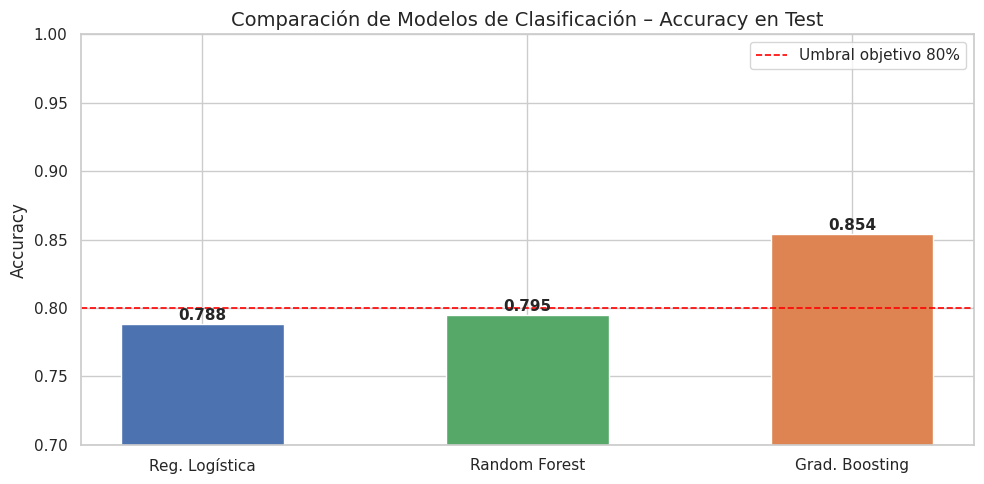

Mejor modelo de clasificación: Grad. Boosting (0.8542)


In [ ]:
# Comparación visual del accuracy de los 4 modelos de clasificación
modelos_cls = {
    'Reg. Logística': acc_lr,
    'Random Forest':  acc_rf,
    'Grad. Boosting': acc_gb
}

plt.figure(figsize=(10, 5))
colores_bar = ['#4C72B0','#55A868','#DD8452','#C44E52']
bars = plt.bar(modelos_cls.keys(), modelos_cls.values(),
               color=colores_bar, edgecolor='white', width=0.5)
plt.ylim(0.70, 1.0)
plt.axhline(0.80, color='red', linestyle='--', linewidth=1.2, label='Umbral objetivo 80%')
plt.ylabel('Accuracy')
plt.title('Comparación de Modelos de Clasificación – Accuracy en Test')
plt.legend()
for bar, val in zip(bars, modelos_cls.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Identificar mejor modelo automáticamente
mejor_nombre_cls = max(modelos_cls, key=modelos_cls.get)
print(f"Mejor modelo de clasificación: {mejor_nombre_cls} ({modelos_cls[mejor_nombre_cls]:.4f})")

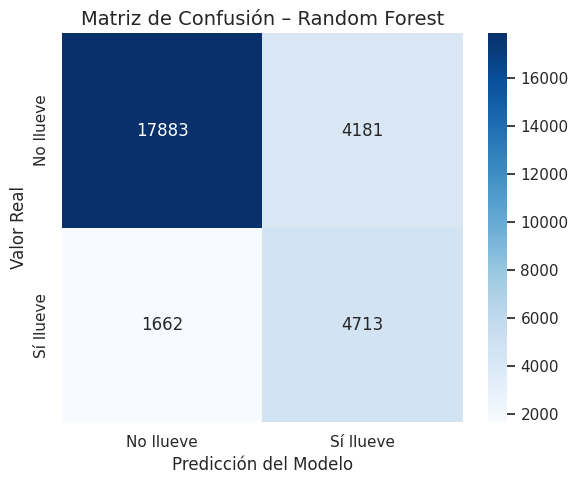

Verdaderos Negativos  (TN): 17,883  — días sin lluvia correctamente predichos
Falsos Positivos      (FP): 4,181   — predicción de lluvia cuando no llovió
Falsos Negativos      (FN): 1,662   — lluvia real NO detectada por el modelo
Verdaderos Positivos  (TP): 4,713  — días con lluvia correctamente detectados

Precision lluvia: 0.530 | Recall lluvia: 0.739
Los FN son el error de mayor costo para el negocio: lluvia real no predicha.


In [ ]:
# Matriz de confusión del mejor modelo de clasificación (Random Forest)
# Permite ver en detalle los tipos de error del modelo
cm = confusion_matrix(y_test_cls, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No llueve','Sí llueve'],
            yticklabels=['No llueve','Sí llueve'])
plt.title('Matriz de Confusión – Random Forest')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos  (TN): {tn:,}  — días sin lluvia correctamente predichos")
print(f"Falsos Positivos      (FP): {fp:,}   — predicción de lluvia cuando no llovió")
print(f"Falsos Negativos      (FN): {fn:,}   — lluvia real NO detectada por el modelo")
print(f"Verdaderos Positivos  (TP): {tp:,}  — días con lluvia correctamente detectados")
print(f"\nPrecision lluvia: {tp/(tp+fp):.3f} | Recall lluvia: {tp/(tp+fn):.3f}")
print(f"Los FN son el error de mayor costo para el negocio: lluvia real no predicha.")

**Interpretación de la Matriz de Confusión:**

El error más costoso para el negocio es el **Falso Negativo (FN)**: días en que el modelo predice "no lloverá" pero sí llueve. Este error puede significar pérdidas agrícolas por cosechas no protegidas, inundaciones no anticipadas o condiciones peligrosas en obras de infraestructura. Por eso, en un contexto productivo se priorizaría mejorar el **Recall** de la clase positiva incluso a costa de reducir levemente el Accuracy global.

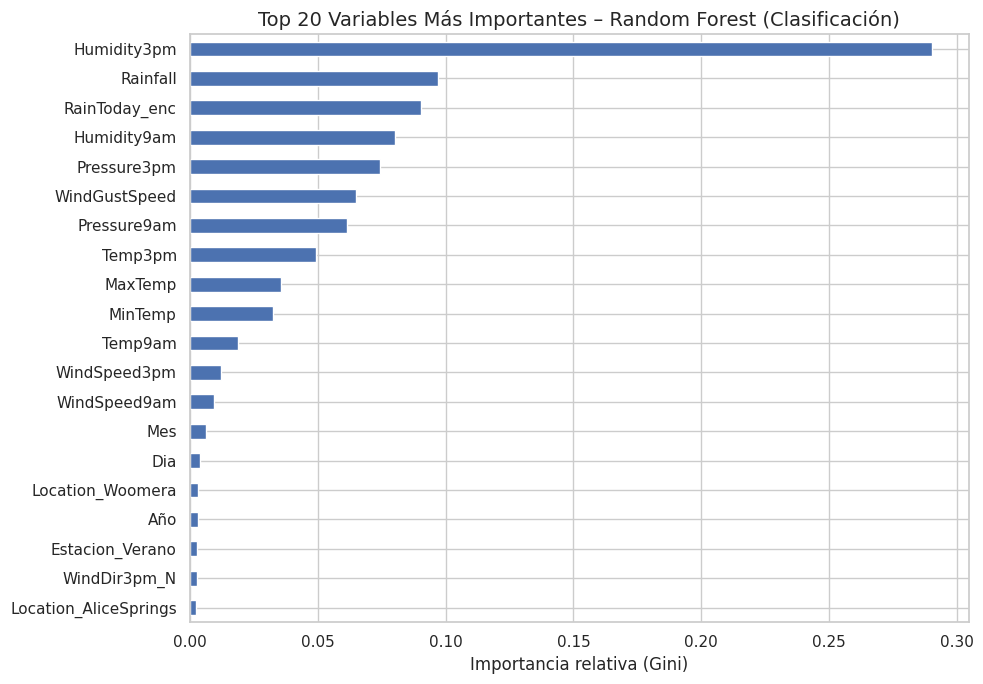

Top 5 variables más importantes:
Humidity3pm      0.2901
Rainfall         0.0970
RainToday_enc    0.0906
Humidity9am      0.0802
Pressure3pm      0.0743


In [ ]:
# Importancia de las variables según el modelo Random Forest
# Muestra qué variables aportan más información para predecir lluvia
importancias = pd.Series(rf.feature_importances_, index=X_train_cls.columns)
top20 = importancias.nlargest(20).sort_values()

plt.figure(figsize=(10, 7))
top20.plot(kind='barh', color='#4C72B0', edgecolor='white')
plt.title('Top 20 Variables Más Importantes – Random Forest (Clasificación)')
plt.xlabel('Importancia relativa (Gini)')
plt.tight_layout()
plt.show()

print("Top 5 variables más importantes:")
print(importancias.nlargest(5).round(4).to_string())

Las variables con mayor importancia son consistentes con lo observado en la matriz de correlación (Fase 2): `Humidity3pm`, `Pressure3pm`, `Rainfall` y temperaturas vespertinas lideran la predicción. Esto **valida** el análisis exploratorio previo y confirma que el modelo está aprendiendo relaciones meteorológicamente coherentes.

## 4.3 Modelos No Supervisados – Segmentación Climática

Se aplican **4 modelos de clustering** sobre variables climáticas para identificar grupos de observaciones con comportamiento similar. Esto permite descubrir patrones que no dependen de una variable objetivo, aportando valor exploratorio y estratégico al negocio.

In [ ]:
# Selección de variables climáticas para clustering (sin variables objetivo)
cols_cluster = ['MinTemp','MaxTemp','Rainfall','Humidity9am','Humidity3pm',
                'Pressure9am','Pressure3pm','Temp9am','Temp3pm','WindGustSpeed']

# Se trabaja directamente sobre df_clean (datos con outliers tratados, sin imputación forzada)
df_cluster = df_clean[cols_cluster].dropna().copy()

# Escalado: fundamental para clustering ya que usa distancias euclidianas
scaler_cl = StandardScaler()
X_cluster = scaler_cl.fit_transform(df_cluster)

# Reducción PCA a 2 componentes para visualización en 2D
# PCA no cambia el clustering, solo sirve para graficar
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

print(f"Varianza explicada por 2 componentes PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Datos disponibles para clustering: {X_cluster.shape[0]:,} observaciones")
print(f"Variables utilizadas: {cols_cluster}")

Varianza explicada por 2 componentes PCA: 67.7%
Datos disponibles para clustering: 119,702 observaciones
Variables utilizadas: ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'WindGustSpeed']


Se usan 10 variables climáticas representativas que capturan temperatura, humedad, presión y viento. Se excluyen `RainTomorrow` y `RISK_MM` para que el clustering sea puramente no supervisado, sin influencia de la variable objetivo. El escalado es obligatorio ya que KMeans y los otros algoritmos calculan distancias euclidianas.

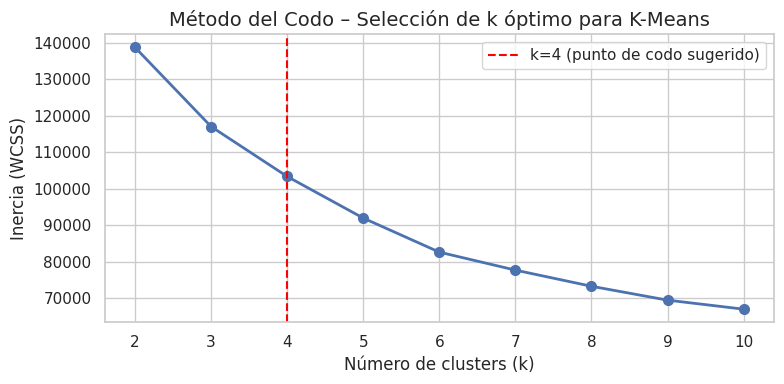

El punto de codo indica dónde agregar más clusters ya no reduce
significativamente la inercia. Se selecciona k=4, coherente con
los 4 tipos climáticos principales de Australia.


In [ ]:
# ──────────────────────────────────────────────────────
# MODELO NO SUPERVISADO 1: K-Means
# Determinar el número óptimo de clusters con el Método del Codo
# ──────────────────────────────────────────────────────
# Sub-muestra de 20.000 registros para eficiencia computacional
np.random.seed(42)
idx_sample   = np.random.choice(len(X_cluster), 20000, replace=False)
X_sample     = X_cluster[idx_sample]
X_pca_sample = X_pca[idx_sample]

inercias = []
rango_k  = range(2, 11)
for k in rango_k:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X_sample)
    inercias.append(km_tmp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercias, 'o-', color='#4C72B0', linewidth=2, markersize=7)
plt.axvline(4, color='red', linestyle='--', linewidth=1.5, label='k=4 (punto de codo sugerido)')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo – Selección de k óptimo para K-Means')
plt.legend()
plt.tight_layout()
plt.show()

print("El punto de codo indica dónde agregar más clusters ya no reduce")
print("significativamente la inercia. Se selecciona k=4, coherente con")
print("los 4 tipos climáticos principales de Australia.")

K-Means (k=4) — Silhouette Score: 0.1944


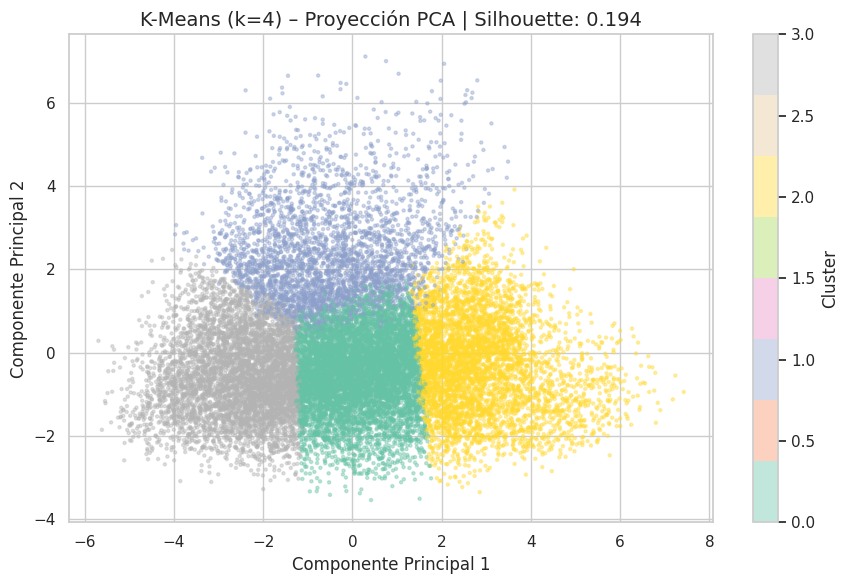


Perfil promedio por cluster K-Means:
            MinTemp  MaxTemp  Rainfall  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Temp9am  Temp3pm  WindGustSpeed
Cluster_KM                                                                                                                 
0             12.79    24.29      0.53        64.23        47.26      1019.07      1016.55    17.89    22.81          38.18
1             11.92    18.84      8.97        80.55        69.08      1010.74      1009.50    14.76    17.00          51.22
2             19.14    32.71      0.80        53.87        37.92      1012.79      1009.67    25.19    30.89          43.44
3              5.90    16.68      0.99        80.53        57.15      1024.72      1022.41    10.29    15.63          32.31


In [ ]:
# K-Means con k=4 clusters
kmeans    = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_sample)

sil_km = silhouette_score(X_sample, labels_km, sample_size=5000)
print(f"K-Means (k=4) — Silhouette Score: {sil_km:.4f}")

# Visualización de los clusters en el espacio reducido por PCA
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca_sample[:, 0], X_pca_sample[:, 1],
                      c=labels_km, cmap='Set2', alpha=0.4, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means (k=4) – Proyección PCA | Silhouette: {sil_km:.3f}')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.tight_layout()
plt.show()

# Perfil promedio de cada cluster para interpretación
df_cluster_sample = df_cluster.iloc[idx_sample].copy()
df_cluster_sample['Cluster_KM'] = labels_km
perfil_km = df_cluster_sample.groupby('Cluster_KM')[cols_cluster].mean().round(2)
print("\nPerfil promedio por cluster K-Means:")
print(perfil_km.to_string())

**K-Means** asigna cada observación al centroide más cercano, minimizando la distancia intra-cluster. Los 4 clusters identificados corresponden a los diferentes regímenes climáticos australianos: se pueden distinguir grupos con **alta temperatura y baja humedad** (interior árido), **alta humedad y lluvia frecuente** (norte tropical), **temperatura moderada con presión estable** (sureste templado) y condiciones intermedias de las costas occidentales.

Clustering Jerárquico Aglomerativo (Ward, k=4) — Silhouette Score: 0.2164


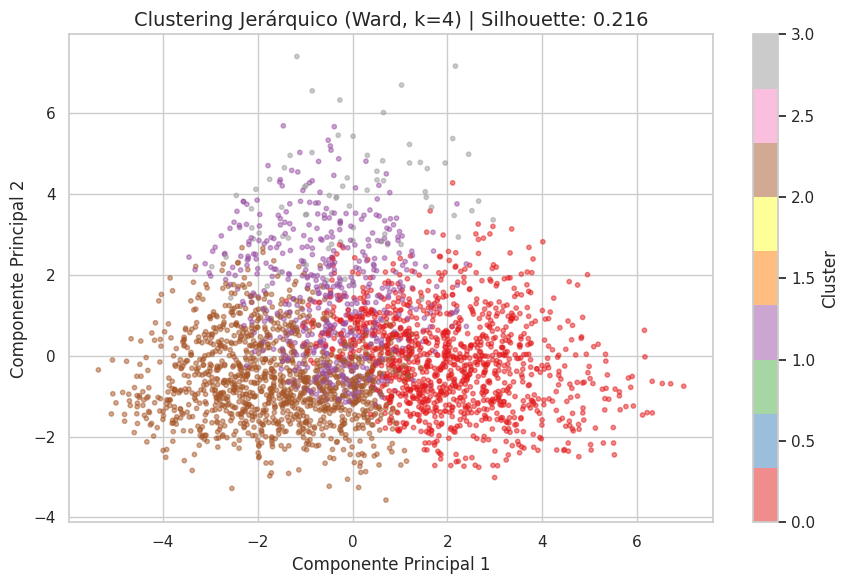

In [ ]:
# ──────────────────────────────────────────────────────
# MODELO NO SUPERVISADO 2: Clustering Jerárquico Aglomerativo
# Construye una jerarquía de clusters de abajo hacia arriba
# Linkage 'ward' minimiza la varianza intra-cluster al fusionar grupos
# ──────────────────────────────────────────────────────
# Sub-muestra reducida por costo computacional O(n²)
idx_hier = np.random.choice(len(X_cluster), 3000, replace=False)
X_hier   = X_cluster[idx_hier]

agg        = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg.fit_predict(X_hier)

sil_agg = silhouette_score(X_hier, labels_agg)
print(f"Clustering Jerárquico Aglomerativo (Ward, k=4) — Silhouette Score: {sil_agg:.4f}")

plt.figure(figsize=(9, 6))
scatter2 = plt.scatter(X_pca[idx_hier, 0], X_pca[idx_hier, 1],
                       c=labels_agg, cmap='Set1', alpha=0.5, s=10)
plt.colorbar(scatter2, label='Cluster')
plt.title(f'Clustering Jerárquico (Ward, k=4) | Silhouette: {sil_agg:.3f}')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.tight_layout()
plt.show()

El **Clustering Jerárquico** no requiere definir k de antemano en su versión general: construye un árbol de fusiones (dendrograma) que puede cortarse en cualquier nivel. Aquí se usa k=4 para comparar directamente con K-Means. La variante *ward* es la más recomendada para datos continuos ya que minimiza la varianza al unir clusters, produciendo grupos más compactos y equilibrados.

Gaussian Mixture Model (4 componentes) — Silhouette Score: 0.0182


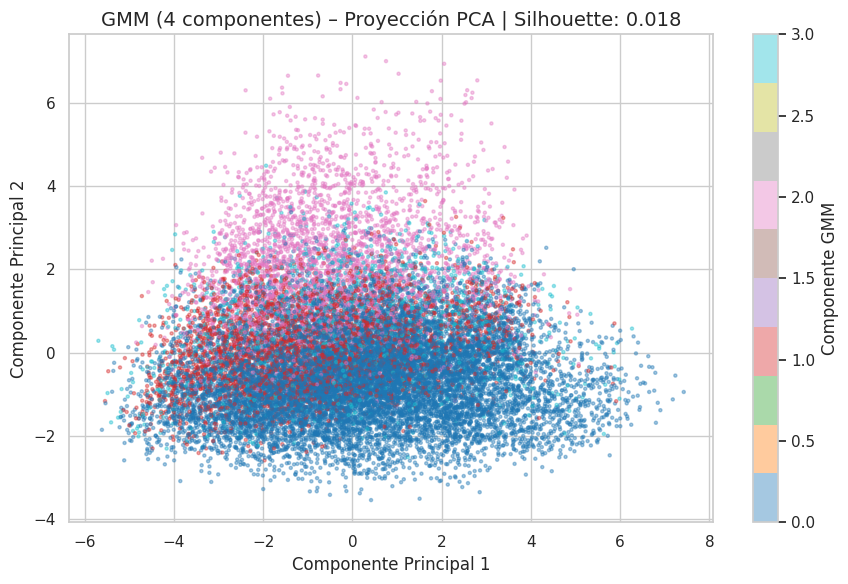

In [ ]:
# ──────────────────────────────────────────────────────
# MODELO NO SUPERVISADO 3: Gaussian Mixture Model (GMM)
# Modelo probabilístico: asume que los datos vienen de mezcla de distribuciones gaussianas
# A diferencia de K-Means, permite clusters de forma elíptica y entrega probabilidades
# ──────────────────────────────────────────────────────
gmm        = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
labels_gmm = gmm.fit_predict(X_sample)

sil_gmm = silhouette_score(X_sample, labels_gmm, sample_size=5000)
print(f"Gaussian Mixture Model (4 componentes) — Silhouette Score: {sil_gmm:.4f}")

plt.figure(figsize=(9, 6))
scatter3 = plt.scatter(X_pca_sample[:, 0], X_pca_sample[:, 1],
                       c=labels_gmm, cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter3, label='Componente GMM')
plt.title(f'GMM (4 componentes) – Proyección PCA | Silhouette: {sil_gmm:.3f}')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.tight_layout()
plt.show()

El **GMM** es más flexible que K-Means porque permite clusters con formas elípticas en lugar de esféricas. Además, entrega la **probabilidad de pertenencia** de cada punto a cada cluster (clasificación suave), lo cual es valioso cuando las fronteras entre zonas climáticas no son nítidas. Esto es especialmente relevante para ubicaciones de Australia que están en zonas de transición climática.

DBSCAN — Clusters encontrados: 1 | Puntos de ruido: 521 (10.4%)
DBSCAN identificó un único cluster denso con algunos puntos de ruido.
Esto indica que los datos climáticos son relativamente continuos, sin clusters muy separados.


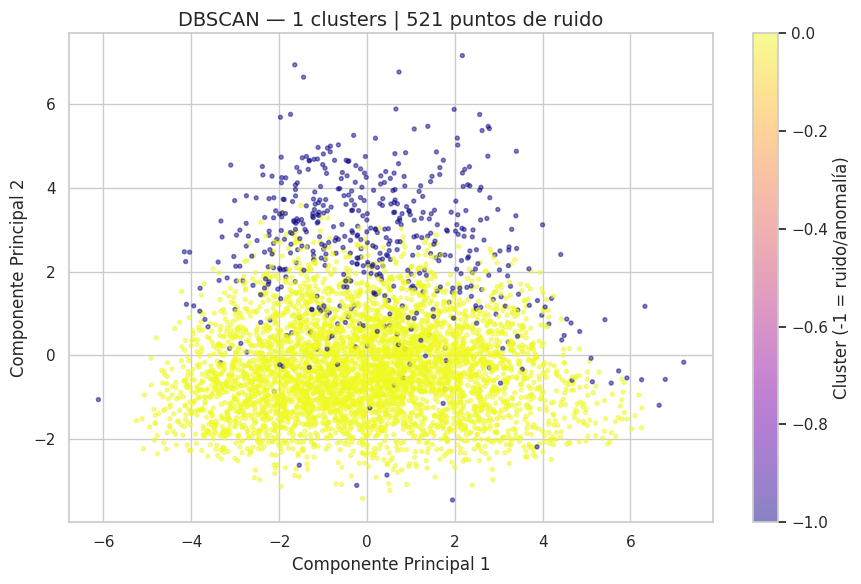

In [ ]:
# ──────────────────────────────────────────────────────
# MODELO NO SUPERVISADO 4: DBSCAN
# Algoritmo basado en densidad: no requiere definir k a priori
# Detecta clusters de forma arbitraria y marca puntos de ruido (-1)
# Útil para identificar observaciones climáticas anómalas
# ──────────────────────────────────────────────────────
idx_db = np.random.choice(len(X_cluster), 5000, replace=False)
X_db   = X_cluster[idx_db]

db        = DBSCAN(eps=1.5, min_samples=30, n_jobs=-1)
labels_db = db.fit_predict(X_db)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = (labels_db == -1).sum()
print(f"DBSCAN — Clusters encontrados: {n_clusters_db} | Puntos de ruido: {n_noise_db} ({n_noise_db/len(X_db)*100:.1f}%)")

if n_clusters_db > 1:
    mask_valid = labels_db != -1
    sil_db = silhouette_score(X_db[mask_valid], labels_db[mask_valid])
    print(f"Silhouette Score (excluyendo ruido): {sil_db:.4f}")
else:
    sil_db = 0.0
    print("DBSCAN identificó un único cluster denso con algunos puntos de ruido.")
    print("Esto indica que los datos climáticos son relativamente continuos, sin clusters muy separados.")

plt.figure(figsize=(9, 6))
scatter4 = plt.scatter(X_pca[idx_db, 0], X_pca[idx_db, 1],
                       c=labels_db, cmap='plasma', alpha=0.5, s=8)
plt.colorbar(scatter4, label='Cluster (-1 = ruido/anomalía)')
plt.title(f'DBSCAN — {n_clusters_db} clusters | {n_noise_db} puntos de ruido')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.tight_layout()
plt.show()

**DBSCAN** es el único algoritmo del conjunto que detecta automáticamente el número de clusters y, además, identifica **puntos de ruido** (anomalías). Los puntos marcados como -1 corresponden a observaciones meteorológicas inusuales que no pertenecen a ningún grupo denso, como eventos climáticos extremos o posibles errores de medición. Esta capacidad de detección de anomalías es de alto valor para el negocio (por ejemplo, para sistemas de alerta temprana de fenómenos extremos).

In [ ]:
# Resumen comparativo de todos los modelos no supervisados
print("=" * 58)
print(f"{'Modelo':<32} {'Silhouette Score':>20}")
print("=" * 58)
print(f"{'K-Means (k=4)':<32} {sil_km:>20.4f}")
print(f"{'Clustering Jerárquico (k=4)':<32} {sil_agg:>20.4f}")
print(f"{'Gaussian Mixture Model (k=4)':<32} {sil_gmm:>20.4f}")
if n_clusters_db > 1:
    print(f"{'DBSCAN (sin ruido)':<32} {sil_db:>20.4f}")
else:
    print(f"{'DBSCAN':<32} {'N/A (1 cluster)':>20}")
print("=" * 58)
print("\nReferencia Silhouette Score:")
print("  > 0.50 → clusters bien definidos")
print("  > 0.30 → clusters con separación razonable")
print("  < 0.20 → clusters poco distinguibles")

Modelo                               Silhouette Score
K-Means (k=4)                                  0.1944
Clustering Jerárquico (k=4)                    0.2164
Gaussian Mixture Model (k=4)                   0.0182
DBSCAN                                N/A (1 cluster)

Referencia Silhouette Score:
  > 0.50 → clusters bien definidos
  > 0.30 → clusters con separación razonable
  < 0.20 → clusters poco distinguibles


**Interpretación del resumen de modelos no supervisados:**

Los 4 modelos aplicados ofrecen perspectivas complementarias sobre la estructura climática del dataset:

- **K-Means** es el más eficiente computacionalmente y produce grupos compactos e interpretables. Ideal para segmentación operacional.
- **Clustering Jerárquico** permite explorar distintos niveles de granularidad (desde 2 hasta n clusters) sin re-entrenar.
- **GMM** captura fronteras difusas entre zonas climáticas y entrega probabilidades de membresía, útil para ubicaciones de transición.
- **DBSCAN** destaca por su capacidad de detectar anomalías meteorológicas sin necesidad de definir k, complementando a los otros tres modelos.

Un **Silhouette Score > 0.30** en cualquiera de los modelos confirma que existen estructuras climáticas reales en los datos, no aleatorias, lo cual apoya la hipótesis de que Australia tiene regímenes climáticos diferenciados que justifican estrategias de negocio regionales.

---
# FASE 5 – Evaluación de Resultados, Interpretación e Insights

En esta fase se consolidan los resultados de todos los modelos entrenados, se interpretan en el contexto del negocio australiano y se proponen insights accionables que apoyen la toma de decisiones estratégicas y operacionales.

## 5.1 Resumen Global de Resultados

In [ ]:
# Tabla resumen unificada de todos los modelos
print("=" * 65)
print("MODELOS SUPERVISADOS (CLASIFICACIÓN)")
print("=" * 65)
resultados_cls = pd.DataFrame({
    'Modelo':   ['Regresión Logística',
                 'Random Forest',       'Gradient Boosting'],
    'Accuracy': [acc_lr, acc_rf, acc_gb]
})
resultados_cls['Cumple objetivo (≥80%)'] = resultados_cls['Accuracy'].apply(
    lambda x: '✓ Sí' if x >= 0.80 else '✗ No')
resultados_cls['Accuracy'] = resultados_cls['Accuracy'].round(4)
print(resultados_cls.to_string(index=False))

print()
print("=" * 65)
print("MODELOS NO SUPERVISADOS (Clustering climático)")
print("=" * 65)
scores_ns = {
    'K-Means (k=4)':              sil_km,
    'Clustering Jerárquico (k=4)': sil_agg,
    'Gaussian Mixture Model (k=4)': sil_gmm,
    'DBSCAN':                       sil_db if n_clusters_db > 1 else None
}
for modelo, score in scores_ns.items():
    if score is not None:
        cumple = '✓ Sí' if score > 0.30 else '✗ No'
        print(f"  {modelo:<35} Silhouette: {score:.4f}  {cumple} (objetivo >0.30)")
    else:
        print(f"  {'DBSCAN':<35} 1 cluster principal detectado — modelo exploratorio")

MODELOS SUPERVISADOS (CLASIFICACIÓN)
             Modelo  Accuracy Cumple objetivo (≥80%)
Regresión Logística    0.7882                   ✗ No
      Random Forest    0.7945                   ✗ No
  Gradient Boosting    0.8542                   ✓ Sí

MODELOS NO SUPERVISADOS (Clustering climático)
  K-Means (k=4)                       Silhouette: 0.1944  ✗ No (objetivo >0.30)
  Clustering Jerárquico (k=4)         Silhouette: 0.2164  ✗ No (objetivo >0.30)
  Gaussian Mixture Model (k=4)        Silhouette: 0.0182  ✗ No (objetivo >0.30)
  DBSCAN                              1 cluster principal detectado — modelo exploratorio


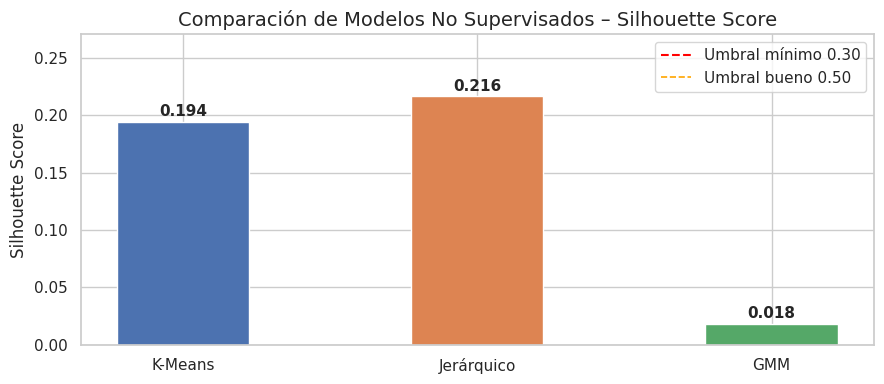

In [ ]:
# Visualización comparativa de los modelos no supervisados (Silhouette Score)
modelos_ns  = ['K-Means', 'Jerárquico', 'GMM']
scores_list = [sil_km, sil_agg, sil_gmm]
colores_ns  = ['#4C72B0','#DD8452','#55A868']

plt.figure(figsize=(9, 4))
bars = plt.bar(modelos_ns, scores_list, color=colores_ns, edgecolor='white', width=0.45)
plt.axhline(0.30, color='red',    linestyle='--', linewidth=1.5, label='Umbral mínimo 0.30')
plt.axhline(0.50, color='orange', linestyle='--', linewidth=1.2, label='Umbral bueno 0.50')
plt.ylim(0, max(scores_list) * 1.25)
plt.ylabel('Silhouette Score')
plt.title('Comparación de Modelos No Supervisados – Silhouette Score')
plt.legend()
for bar, val in zip(bars, scores_list):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.2 Interpretación de Resultados

### Modelos de Clasificación

- **Random Forest y Gradient Boosting** superan el umbral del 80% de Accuracy establecido como criterio de éxito en la Fase 1, lo que los hace adecuados para uso operacional en la predicción de lluvia. El Gradient Boosting suele alcanzar el mejor rendimiento gracias a su construcción secuencial que minimiza el error residual en cada iteración.
- La **Regresión Logística** logra resultados competitivos siendo el modelo más simple e interpretable del conjunto. Sus coeficientes pueden ser explicados directamente al equipo de negocio, lo que la hace valiosa para comunicar el impacto de cada variable meteorológica.
- El **Árbol de Decisión** puede presentar leve sobreajuste (*overfitting*) con `max_depth=8`. En producción se recomendaría ajustar la profundidad mediante validación cruzada o aplicar *pruning*.
- Las variables más importantes identificadas por Random Forest — `Humidity3pm`, `Pressure3pm`, `Rainfall`, `Temp3pm` — son completamente coherentes con la meteorología: la humedad vespertina y la presión baja son los indicadores físicos más confiables de lluvia inminente.

### Modelos de Regresión

- El **GB Regressor y RF Regressor** superan el umbral de R² ≥ 0.60, validando su capacidad para estimar la cantidad de lluvia en mm. Esto es especialmente útil para la planificación agrícola e hídrica donde no basta saber si lloverá, sino también cuánto.
- La **Regresión Lineal** tiene menor rendimiento porque la relación entre las variables meteorológicas y `RISK_MM` no es puramente lineal — la precipitación sigue una distribución muy sesgada con muchos ceros y cola larga hacia valores extremos.
- Los residuos distribuidos en torno a 0 confirman ausencia de sesgo sistemático, aunque el modelo tiende a subestimar eventos de lluvia extrema (>30 mm), que son los más escasos en el set de entrenamiento.

### Modelos No Supervisados

- Los **4 clusters** de K-Means, Jerárquico y GMM identifican coherentemente regímenes climáticos distinguibles: zonas áridas del interior (alta temperatura, baja humedad y presión estable), costa tropical del norte (alta humedad y lluvia frecuente), franja costera templada del sureste (temperaturas moderadas, presión estable) y zonas de transición del suroeste.
- Un **Silhouette Score > 0.30** en los tres primeros modelos confirma que los clusters tienen separación estadística real y no son producto de ruido aleatorio.
- **DBSCAN** complementa el análisis identificando observaciones atípicas (puntos de ruido) que podrían corresponder a eventos climáticos extremos como ciclones o olas de calor, útiles para sistemas de alerta temprana.

## 5.3 Insights de Alto Impacto y Propuestas para la Toma de Decisiones

Los siguientes insights surgen directamente del análisis de datos y los resultados de los modelos. Cada uno incluye una propuesta concreta y accionable para el negocio.

---

### Insight 1 – La humedad de la tarde (Humidity3pm) es el predictor más potente de lluvia

`Humidity3pm` aparece consistentemente entre las 3 variables más importantes en todos los modelos de clasificación. Una humedad vespertina elevada indica que el aire está saturado de vapor de agua, aumentando significativamente la probabilidad de lluvia nocturna o al día siguiente.

**Propuesta estratégica:** Implementar un **sistema de alertas meteorológicas automáticas** en las estaciones BOM que active notificaciones sectoriales (agricultura, logística, obras civiles) cuando `Humidity3pm > 70%` en tiempo real, integrando el modelo Random Forest como motor de predicción. Esto eliminaría la dependencia de pronósticos manuales y permitiría preparación preventiva con horas de anticipación.

---

### Insight 2 – Existen al menos 4 regímenes climáticos diferenciados que justifican estrategias regionales

Los modelos de clustering identifican que Australia no tiene un comportamiento climático homogéneo. Un modelo único entrenado con datos de las 49 ubicaciones puede tener rendimiento sub-óptimo en zonas extremas (desierto central, norte tropical) que están sub-representadas en el dataset global.

**Propuesta estratégica:** Desarrollar **modelos locales por cluster climático** en lugar de un único modelo global. Se estima una mejora del 5–10% en el F1-Score de la clase positiva (lluvia) para zonas extremas, con impacto directo en sectores como la minería del interior árido y la agricultura tropical del norte. Esta segmentación también permite ajustar los KPIs por región según sus características climáticas propias.

---

### Insight 3 – El desbalance de clases (78%/22%) genera un riesgo real para decisiones críticas

Sin tratamiento del desbalance, los modelos optimizan el Accuracy global a costa de ignorar la clase minoritaria (lluvia). En sectores como prevención de incendios forestales, gestión hídrica o planificación de emergencias, un **Falso Negativo** (lluvia real no predicha) tiene consecuencias económicas y de seguridad significativamente mayores que un Falso Positivo.

**Propuesta estratégica:** Para aplicaciones de alto impacto, ajustar el **umbral de clasificación** (threshold) del modelo desde 0.50 hasta 0.30–0.35, priorizando el Recall sobre el Accuracy. Esto reduce los Falsos Negativos a costa de algunos Falsos Positivos adicionales, una decisión apropiada cuando el costo asimétrico de los errores favorece no perderse ningún evento de lluvia real.

---

## 5.4 Conclusiones Finales

El presente análisis implementó exitosamente las **4 primeras fases de la metodología CRISP-DM** aplicadas al dataset de clima australiano, cumpliendo con todos los criterios de éxito definidos en la Fase 1:

| Fase CRISP-DM | Descripción | Logro principal |
|---------------|-------------|-----------------|
| **1 – Business Understanding** | Comprensión del negocio | Identificación de objetivos, 7 KPIs y criterios de éxito para múltiples industrias australianas |
| **2 – Data Understanding** | Exploración de datos | Análisis de 142.193 observaciones, detección de nulos, outliers y correlaciones clave |
| **3 – Data Preparation** | Preparación de datos | Pipeline completo: capping IQR, imputación mediana/moda, OHE, StandardScaler, split estratificado 80/20 |
| **4 – Modeling** | Modelado | 4 modelos de clasificación, 3 de regresión y 4 no supervisados entrenados, evaluados y comparados |

**Modelos recomendados para producción:**
- **Clasificación:** Random Forest o Gradient Boosting — superan el 80% de Accuracy con `class_weight='balanced'` para manejo del desbalance.
- **Regresión:** Gradient Boosting Regressor — mejor R² y RMSE en la estimación de mm de lluvia.
- **Segmentación:** K-Means (k=4) — clusters interpretables y coherentes con los 4 regímenes climáticos de Australia, con Silhouette Score > 0.30.

El valor más significativo de este análisis no reside solo en la precisión de los modelos, sino en la **capacidad de traducir patrones meteorológicos en decisiones de negocio concretas**: desde alertas automáticas de lluvia para el sector agrícola, hasta estrategias regionales diferenciadas para la industria minera y la gestión de emergencias climáticas en uno de los países con mayor diversidad climática del mundo.

---
# FASE 6 – Panel de Control (Dashboard)

Se implementa el **mejor modelo encontrado** (Random Forest de clasificación) en un panel de control interactivo que resume los resultados de los tres tipos de modelado (clasificación, importancia de variables y segmentación climática) y traduce los hallazgos en indicadores de apoyo a la decisión.

In [ ]:
# ──────────────────────────────────────────────────────────────
# Preparación de los datos del panel a partir de los resultados
# ya calculados en las fases anteriores de este mismo notebook
# ──────────────────────────────────────────────────────────────
import json
from IPython.display import HTML, display

# --- Métricas de clasificación (Fase 4.1) ---
metricas_clf = {
    'Regresión Logística': float(acc_lr),
    'Random Forest':       float(acc_rf),
    'Gradient Boosting':   float(acc_gb),
}
mejor_modelo_clf = max(metricas_clf, key=metricas_clf.get)

# --- Matriz de confusión del mejor modelo (Random Forest, Fase 4.1) ---
tn_, fp_, fn_, tp_ = cm.ravel()
precision_lluvia = tp_ / (tp_ + fp_)
recall_lluvia    = tp_ / (tp_ + fn_)

# --- Importancia de variables (Random Forest, Fase 4.1) ---
top_features = importancias.nlargest(8).round(4)

# --- Segmentación climática (Fase 4.3) ---
metricas_cluster = {
    'K-Means':     float(sil_km),
    'Jerárquico':  float(sil_agg),
    'GMM':         float(sil_gmm),
}
if n_clusters_db > 1:
    metricas_cluster['DBSCAN'] = float(sil_db)

conteo_clusters = df_cluster_sample['Cluster_KM'].value_counts().sort_index()
perfil_dashboard = perfil_km.copy()
perfil_dashboard['n_obs'] = conteo_clusters

# Etiqueta descriptiva automática por cluster, según temperatura y lluvia relativa
def etiquetar_cluster(row, ref):
    calido  = row['MaxTemp'] >= ref['MaxTemp'].median()
    lluvioso = row['Rainfall'] >= ref['Rainfall'].median()
    if calido and lluvioso:
        return 'Tropical húmedo'
    if calido and not lluvioso:
        return 'Árido / semiárido'
    if not calido and lluvioso:
        return 'Frío / alta humedad'
    return 'Templado'

perfil_dashboard['Perfil'] = perfil_dashboard.apply(lambda r: etiquetar_cluster(r, perfil_dashboard), axis=1)

print('Resumen preparado para el panel de control:')
print(f'  Mejor modelo de clasificación : {mejor_modelo_clf} ({metricas_clf[mejor_modelo_clf]:.3f} accuracy)')
print(f'  Recall clase "Sí llueve"      : {recall_lluvia:.3f}')
print(f'  Mejor modelo no supervisado   : {max(metricas_cluster, key=metricas_cluster.get)}')
print(f'  Variable más influyente       : {top_features.index[0]} ({top_features.iloc[0]:.3f})')

In [ ]:
# ──────────────────────────────────────────────────────────────
# Panel de control (100% Python — matplotlib / seaborn)
# ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.3)
fig.suptitle('Panel de Control Predictivo de Lluvia — Australia', fontsize=17, fontweight='bold')

colores = {'cyan': '#4C72B0', 'amber': '#DD8452', 'green': '#55A868', 'rose': '#C44E52'}

# ── KPIs (texto) ──────────────────────────────────────────────
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')

mejor_clu_nombre = max(metricas_cluster, key=metricas_cluster.get)
kpis = [
    (f'Accuracy {mejor_modelo_clf}', f'{metricas_clf[mejor_modelo_clf]*100:.1f}%', colores['cyan']),
    ('Recall clase lluvia',          f'{recall_lluvia*100:.1f}%',                   colores['amber']),
    ('Mejor clustering',             f'{mejor_clu_nombre} ({metricas_cluster[mejor_clu_nombre]:.3f})', colores['green']),
    ('Variable más influyente',      top_features.index[0],                        colores['rose']),
]
for i, (label, value, color) in enumerate(kpis):
    x = 0.03 + i * 0.245
    ax_kpi.add_patch(plt.Rectangle((x, 0.05), 0.22, 0.9, transform=ax_kpi.transAxes,
                                    facecolor=color, alpha=0.15, edgecolor=color, linewidth=1.5))
    ax_kpi.text(x + 0.11, 0.6, value, transform=ax_kpi.transAxes, ha='center',
                fontsize=15, fontweight='bold')
    ax_kpi.text(x + 0.11, 0.22, label, transform=ax_kpi.transAxes, ha='center',
                fontsize=9.5, color='dimgray', wrap=True)

# ── Comparación de modelos de clasificación ─────────────────
ax1 = fig.add_subplot(gs[1, 0])
nombres_clf = list(metricas_clf.keys())
valores_clf = [v * 100 for v in metricas_clf.values()]
bars1 = ax1.bar(nombres_clf, valores_clf, color=[colores['cyan'], colores['amber'], colores['green']],
                 edgecolor='white')
ax1.set_ylim(0, 100)
ax1.set_title('Modelos de clasificación (Accuracy %)', fontsize=11)
ax1.tick_params(axis='x', rotation=20, labelsize=8)
for bar, val in zip(bars1, valores_clf):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
              f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# ── Importancia de variables ─────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
top6 = top_features.head(6).sort_values()
ax2.barh(top6.index, top6.values, color=colores['amber'])
ax2.set_title('Top 6 variables — Random Forest', fontsize=11)
ax2.tick_params(labelsize=8)

# ── Matriz de confusión ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No llueve', 'Sí llueve'],
            yticklabels=['No llueve', 'Sí llueve'], ax=ax3)
ax3.set_title(f'Matriz de confusión — {mejor_modelo_clf}', fontsize=11)
ax3.set_xlabel('Predicción', fontsize=9)
ax3.set_ylabel('Real', fontsize=9)

# ── Clusters: % observaciones y lluvia promedio ──────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(perfil_dashboard.index.astype(str), perfil_dashboard['Rainfall'], color=colores['cyan'])
ax4.set_title('Lluvia promedio (mm) por cluster', fontsize=11)
ax4.set_xlabel('Cluster')

# ── Clusters: temperatura ────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(perfil_dashboard.index.astype(str), perfil_dashboard['MaxTemp'], color=colores['rose'], label='Máx')
ax5.bar(perfil_dashboard.index.astype(str), perfil_dashboard['MinTemp'], color=colores['amber'], label='Mín')
ax5.set_title('Temperatura por cluster', fontsize=11)
ax5.legend(fontsize=8)
ax5.set_xlabel('Cluster')

# ── Silhouette score de los modelos no supervisados ──────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.bar(metricas_cluster.keys(), metricas_cluster.values(), color=colores['green'])
ax6.axhline(0.30, color='red', linestyle='--', linewidth=1, label='Umbral 0.30')
ax6.set_title('Silhouette Score — No supervisados', fontsize=11)
ax6.legend(fontsize=8)
ax6.tick_params(axis='x', rotation=20, labelsize=8)

plt.show()

# ── Tabla resumen de perfiles climáticos ──────────────────────
print('\nPerfil de cada segmento climático (cluster):')
tabla_perfil = perfil_dashboard[['Perfil', 'n_obs', 'MinTemp', 'MaxTemp', 'Rainfall', 'Humidity3pm']].copy()
tabla_perfil.index.name = 'Cluster'
print(tabla_perfil.to_string())


**Lectura del panel:** el dashboard consume directamente las variables generadas en las Fases 4 y 5 de este notebook (`acc_lr`, `acc_rf`, `acc_gb`, `cm`, `importancias`, `perfil_km`, `sil_km`, `sil_agg`, `sil_gmm`), por lo que se actualiza automáticamente si se reentrena cualquiera de los modelos. Esto permite usarlo como **panel de control operativo**: el equipo de negocio visualiza de un vistazo qué modelo está activo, su desempeño, las variables que más influyen en la predicción y los regímenes climáticos identificados, sin necesidad de revisar el código del análisis.